In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon, box
import numpy as np
import h3
import os
import random
from datetime import datetime, timedelta
import contextily as cx
import matplotlib.pyplot as plt
from pathlib import Path
import contextily as ctx

In [ ]:
INPUT_FILE = "chargingStats.csv" 

DATA_VARIANT = "full"             # "small" or "full"
SHRINK_FACTOR = 0.08  

DAY_START = 1                       # aggregate from Day x
DAY_END = 4                         # aggregate through Day y
EXPECTED_DAYS = list(range(DAY_START, DAY_END + 1))
SLOT_MINUTES = 30

FULL_SCENARIO_EVS = 105_940         # full 50% scenario EV fleet
SAMPLE_RATE = 0.10                  # MATSim 10% sampled run
SAMPLE_SCENARIO_EVS = FULL_SCENARIO_EVS * SAMPLE_RATE
FULL_SCALE_FACTOR = 1 / SAMPLE_RATE

# Spatial settings
CRS_PROJECTED = "EPSG:3006"         # SWEREF99 TM, meters
HEX_SIZE = 500                      # hexagon side length in meters
GRID_COVER_BUFFER_FACTOR = 2.0
DROP_NO_EDGE_NEIGHBOR_CELLS = True
KEEP_ONLY_LARGEST_EDGE_CONNECTED_COMPONENT = False
MIN_SHARED_EDGE_LENGTH_M = HEX_SIZE * 0.25

# Small/full output mode
DATA_VARIANT = DATA_VARIANT.lower().strip()
if DATA_VARIANT not in {"small", "full"}:
    raise ValueError("DATA_VARIANT must be either 'small' or 'full'.")

USE_SHRUNK_BBOX_SAMPLE = DATA_VARIANT == "small"
if USE_SHRUNK_BBOX_SAMPLE and not (0 <= SHRINK_FACTOR < 0.5):
    raise ValueError("For small runs, SHRINK_FACTOR must be >= 0 and < 0.5.")

SHRINK_FACTOR_PCT = int(round(SHRINK_FACTOR * 100))
sample_tag = f"shrunk{SHRINK_FACTOR_PCT:02d}" if USE_SHRUNK_BBOX_SAMPLE else "full"
dataset_tag = f"{DATA_VARIANT}_{sample_tag}"

PROJECT_RAW_ROOT = Path(r"C:\Users\omkarp\Downloads\Opti\data\raw")
RAW_OUTPUT_DIR = PROJECT_RAW_ROOT / DATA_VARIANT
RAW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("30minData") / dataset_tag
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMAND_FILE_NAME = f"demandHexGrid_optimization_{sample_tag}.gpkg"
CHARPARK_FILE_STEM = "CharParksmall" if DATA_VARIANT == "small" else "CharParkfull"

OUT_DEMAND_GPKG = RAW_OUTPUT_DIR / DEMAND_FILE_NAME
OUT_DISTANCE_CSV = RAW_OUTPUT_DIR / "shortestpath.csv"
OUT_CHARPARK_SHP = RAW_OUTPUT_DIR / f"{CHARPARK_FILE_STEM}.shp"
OUT_CHARPARK_GPKG = RAW_OUTPUT_DIR / f"{CHARPARK_FILE_STEM}.gpkg"

ROADS_PATH = Path(r"C:\Users\omkarp\Downloads\Opti2\OptiData\Shortest\GotRds.shp")
PARKING_PATH = Path(r"C:\Users\omkarp\Downloads\Opti2\OptiData\Parking\GOTpark.shp")
SOLAR_PATH = Path(r"C:\Users\omkarp\Downloads\Opti2\OptiData\Solar\shpfile\IdealPVinstall.shp")
HOMECHARGING_PATH = Path(r"C:\Users\omkarp\Downloads\Opti2\OptiData\HomeCharging\GOTbldgs.shp")

SAVE_FIGURES = True
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
BASEMAP_ALPHA = 0.80
try:
    BASEMAP_SOURCE = ctx.providers.CartoDB.Positron
except Exception:
    BASEMAP_SOURCE = None

print("Data-generation configuration")
print(f"- DATA_VARIANT: {DATA_VARIANT}")
print(f"- USE_SHRUNK_BBOX_SAMPLE: {USE_SHRUNK_BBOX_SAMPLE}")
print(f"- SHRINK_FACTOR: {SHRINK_FACTOR:.2f}")
print(f"- sample_tag: {sample_tag}")
print(f"- OUTPUT_DIR: {OUTPUT_DIR}")
print()
print("Final optimization-output paths")
print(f"- Demand GPKG:   {OUT_DEMAND_GPKG}")
print(f"- Shortest path: {OUT_DISTANCE_CSV}")
print(f"- Parking SHP:   {OUT_CHARPARK_SHP}")
print(f"- Parking GPKG:  {OUT_CHARPARK_GPKG}")

Data-generation configuration
- DATA_VARIANT: full
- USE_SHRUNK_BBOX_SAMPLE: False
- SHRINK_FACTOR: 0.08
- sample_tag: full
- OUTPUT_DIR: 30minData\full_full

Final optimization-output paths
- Demand GPKG:   C:\Users\omkarp\Downloads\Opti\data\raw\full\demandHexGrid_optimization_full.gpkg
- Shortest path: C:\Users\omkarp\Downloads\Opti\data\raw\full\shortestpath.csv
- Parking SHP:   C:\Users\omkarp\Downloads\Opti\data\raw\full\CharParkfull.shp
- Parking GPKG:  C:\Users\omkarp\Downloads\Opti\data\raw\full\CharParkfull.gpkg


In [ ]:
print("Configured run:")
print(f"- DATA_VARIANT: {DATA_VARIANT}")
print(f"- sample_tag: {sample_tag}")
print(f"- dataset_tag: {dataset_tag}")
print()
print("Files that will be generated for optimization:")
print(f"shapefileDemands = r\"{OUT_DEMAND_GPKG}\"")
print(f"csv_distance_path = r\"{OUT_DISTANCE_CSV}\"")
print(f"parking   = r\"{OUT_CHARPARK_SHP}\"")

Configured run:
- DATA_VARIANT: full
- sample_tag: full
- dataset_tag: full_full

Files that will be generated for optimization:
shapefileDemands = r"C:\Users\omkarp\Downloads\Opti\data\raw\full\demandHexGrid_optimization_full.gpkg"
csv_distance_path = r"C:\Users\omkarp\Downloads\Opti\data\raw\full\shortestpath.csv"
parking   = r"C:\Users\omkarp\Downloads\Opti\data\raw\full\CharParkfull.shp"


In [ ]:
data = pd.read_csv(INPUT_FILE, sep=";")

for col in ["startTime", "endTime", "chargingDuration", "transmittedEnergy_kWh"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna(subset=["startTime", "endTime", "chargingDuration", "transmittedEnergy_kWh"])

data["startTime_hrs"] = data["startTime"] / 3600.0
data["endTime_hrs"] = data["endTime"] / 3600.0
data["chargingDuration_hrs"] = data["chargingDuration"] / 3600.0

# Classify charger type from chargerId
def classify_charger_type(charger_id):
    charger_id = str(charger_id)
    if charger_id.endswith("_home"):
        return "home"
    elif charger_id.endswith("_work"):
        return "work"
    elif charger_id.startswith("public"):
        return "public"
    else:
        return "unknown"

data["chargerType"] = data["chargerId"].apply(classify_charger_type)

print("Charger type counts:")
print(data["chargerType"].value_counts(dropna=False))

Charger type counts:
chargerType
home      16338
public    10852
work       3402
Name: count, dtype: int64


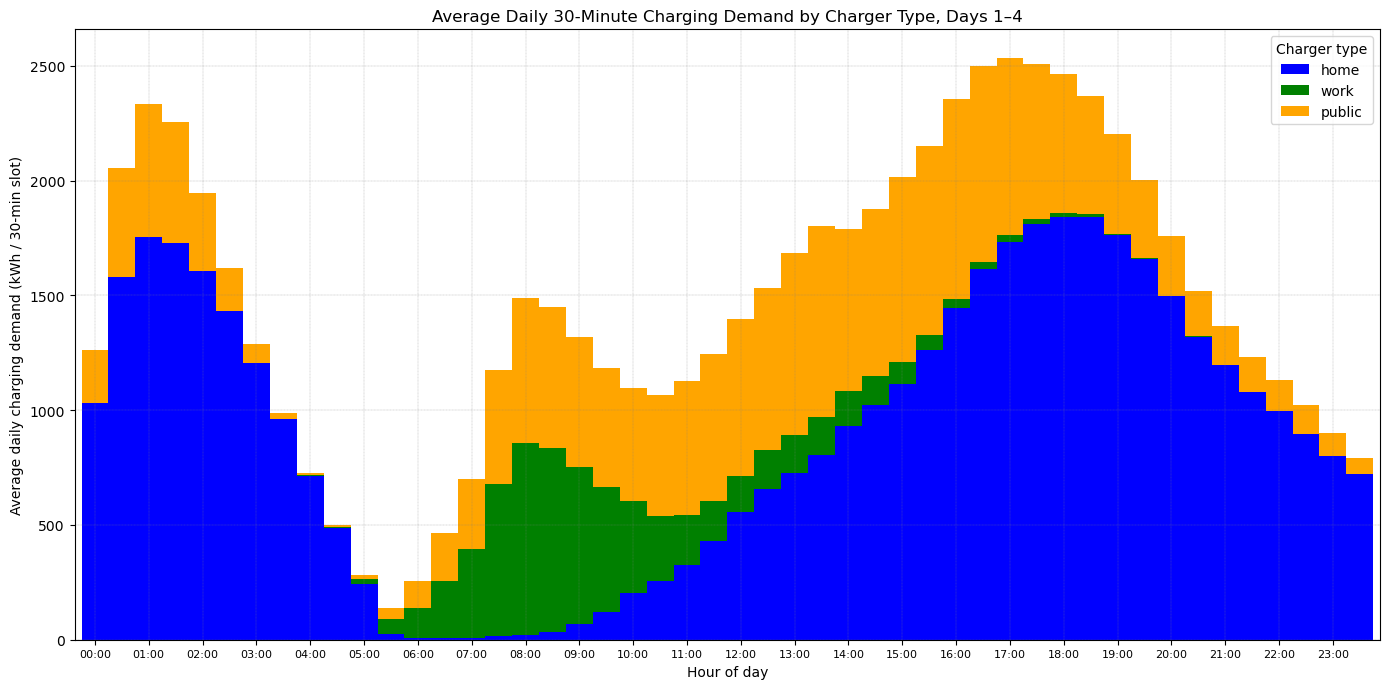

Aggregation window: Day 1 to Day 4 inclusive
Number of days aggregated: 4
Unique EVs charging at least once in selected window: 8,683

Daily total charging demand by charger type within selected window:
           home    work    public
Day 1  40300.55  8214.0  21221.98
Day 2  52894.70  7416.0  23087.87
Day 3  45762.42  6051.0  20012.99
Day 4  35281.51  5187.0  18060.15

Charging demand summary by charger type:
        Total over selected days (kWh)  Share of total over selected days (%)  \
home                         174239.18                                  61.46   
work                          26868.00                                   9.48   
public                        82382.98                                  29.06   

        Average daily demand (kWh/day)  Average daily share (%)  
home                          43559.79                    61.46  
work                           6717.00                     9.48  
public                        20595.75                    29.0

In [ ]:
def aggregate_charging_profile(
    df,
    day_start=2,
    day_end=5,
    slot_minutes=30,
    categories=("home", "work", "public")
):
    """
    Aggregates charging events into 30-minute slots.

    Days are interpreted as:
        Day 1 = 00:00–24:00
        Day 2 = 24:00–48:00
        ...
    
    Energy is allocated proportionally by temporal overlap between each
    charging event and each time slot. This avoids minute-loop rounding errors.
    """

    seconds_per_day = 24 * 3600
    slot_seconds = slot_minutes * 60
    slots_per_day = int(24 * 60 / slot_minutes)

    window_start = (day_start - 1) * seconds_per_day
    window_end = day_end * seconds_per_day
    n_days = day_end - day_start + 1

    categories = list(categories)
    cat_to_idx = {cat: idx for idx, cat in enumerate(categories)}

    # Array: day × time_slot × charger_type
    agg = np.zeros((n_days, slots_per_day, len(categories)))

    # Keep only events overlapping the selected window
    df_window = df[
        (df["endTime"] > window_start) &
        (df["startTime"] < window_end) &
        (df["chargerType"].isin(categories))
    ].copy()

    for _, row in df_window.iterrows():
        start = max(float(row["startTime"]), window_start)
        end = min(float(row["endTime"]), window_end)
        duration = float(row["chargingDuration"])
        energy = float(row["transmittedEnergy_kWh"])
        charger_type = row["chargerType"]

        if end <= start or duration <= 0 or energy <= 0:
            continue

        # Constant charging-rate assumption within the event
        energy_rate_kwh_per_second = energy / duration

        first_slot = int((start - window_start) // slot_seconds)
        last_slot = int(np.ceil((end - window_start) / slot_seconds) - 1)

        for absolute_slot in range(first_slot, last_slot + 1):
            slot_start = window_start + absolute_slot * slot_seconds
            slot_end = slot_start + slot_seconds

            overlap_seconds = max(0, min(end, slot_end) - max(start, slot_start))

            if overlap_seconds <= 0:
                continue

            day_idx = absolute_slot // slots_per_day
            slot_idx = absolute_slot % slots_per_day
            cat_idx = cat_to_idx[charger_type]

            if 0 <= day_idx < n_days:
                agg[day_idx, slot_idx, cat_idx] += energy_rate_kwh_per_second * overlap_seconds

    # Time-of-day index: 0.0, 0.5, 1.0, ..., 23.5
    time_index = np.arange(slots_per_day) * (slot_minutes / 60.0)

    total_profile = pd.DataFrame(
        agg.sum(axis=0),
        index=time_index,
        columns=categories
    )

    average_daily_profile = pd.DataFrame(
        agg.mean(axis=0),
        index=time_index,
        columns=categories
    )

    daily_totals = pd.DataFrame(
        agg.sum(axis=1),
        columns=categories,
        index=[f"Day {d}" for d in range(day_start, day_end + 1)]
    )

    return average_daily_profile, total_profile, daily_totals, df_window


average_daily_profile, total_profile, daily_totals, data_window = aggregate_charging_profile(
    data,
    day_start=DAY_START,
    day_end=DAY_END,
    slot_minutes=SLOT_MINUTES,
    categories=("home", "work", "public")
)

n_days = DAY_END - DAY_START + 1
PLOT_AVERAGE_DAILY_PROFILE = True

if PLOT_AVERAGE_DAILY_PROFILE:
    plot_data = average_daily_profile
    plot_title = f"Average Daily 30-Minute Charging Demand by Charger Type, Days {DAY_START}–{DAY_END}"
    y_label = "Average daily charging demand (kWh / 30-min slot)"
else:
    plot_data = total_profile
    plot_title = f"Total 30-Minute Charging Demand by Charger Type, Days {DAY_START}–{DAY_END}"
    y_label = "Total charging demand (kWh / 30-min slot)"


color_map = {
    "home": "blue",
    "work": "green",
    "public": "orange"
}

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=[color_map[col] for col in plot_data.columns],
    width=1.0
)

ax.set_title(plot_title)
ax.set_xlabel("Hour of day")
ax.set_ylabel(y_label)
ax.set_xticks(range(0, len(plot_data), 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=0, fontsize=8)

plt.legend(title="Charger type")
plt.grid(True, color="grey", linewidth=0.2, linestyle="--")
plt.tight_layout()
plt.show()

total_by_type = total_profile.sum()
total_energy = total_by_type.sum()
share_by_type = 100 * total_by_type / total_energy

average_daily_by_type = average_daily_profile.sum()
average_daily_total = average_daily_by_type.sum()
average_daily_share = 100 * average_daily_by_type / average_daily_total

active_charging_evs = data_window["vehicleId"].nunique()

avg_kwh_per_active_charging_ev_per_day = total_energy / active_charging_evs / n_days
avg_kwh_per_sample_scenario_ev_per_day = total_energy / SAMPLE_SCENARIO_EVS / n_days

print(f"Aggregation window: Day {DAY_START} to Day {DAY_END} inclusive")
print(f"Number of days aggregated: {n_days}")
print(f"Unique EVs charging at least once in selected window: {active_charging_evs:,}")
print()

print("Daily total charging demand by charger type within selected window:")
print(daily_totals.round(2))
print()

summary = pd.DataFrame({
    "Total over selected days (kWh)": total_by_type,
    "Share of total over selected days (%)": share_by_type,
    "Average daily demand (kWh/day)": average_daily_by_type,
    "Average daily share (%)": average_daily_share
})

print("Charging demand summary by charger type:")
print(summary.round(2))
print()

print(f"Total charging demand over Days {DAY_START}–{DAY_END}: {total_energy:,.2f} kWh")
print(f"Average daily charging demand: {average_daily_total:,.2f} kWh/day")
print()

print("Average daily charging per EV:")
print(f"- Per active charging EV: {avg_kwh_per_active_charging_ev_per_day:.2f} kWh/EV/day")
print(f"- Per full sample-scenario EV, including EVs with no charge in this window: {avg_kwh_per_sample_scenario_ev_per_day:.2f} kWh/EV/day")
print()

print("Optimization-ready merged public demand check:")
public_merged_total = total_by_type["work"] + total_by_type["public"]
home_total = total_by_type["home"]
merged_total = home_total + public_merged_total

print(f"- Home: {home_total:,.2f} kWh ({100 * home_total / merged_total:.2f}%)")
print(f"- Public merged = work + public: {public_merged_total:,.2f} kWh ({100 * public_merged_total / merged_total:.2f}%)")

In [ ]:
OUTPUT_EVENT_SLOT_FILE = f"charging_30min_event_slots_day{DAY_START}_to_day{DAY_END}.csv"
OUTPUT_TEMPORAL_BY_TYPE_FILE = f"temporal_30min_by_type_day{DAY_START}_to_day{DAY_END}.csv"
OUTPUT_TEMPORAL_OPT_FILE = f"temporal_30min_home_public_for_optimization_day{DAY_START}_to_day{DAY_END}.csv"

try:
    data
except NameError:
    data = pd.read_csv(INPUT_FILE, sep=";")

data = data.copy()

numeric_cols = [
    "startTime", "endTime", "chargingDuration",
    "transmittedEnergy_kWh", "xCoord", "yCoord"
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data = data.dropna(
    subset=[
        "startTime", "endTime", "chargingDuration",
        "transmittedEnergy_kWh", "xCoord", "yCoord",
        "chargerId", "vehicleId"
    ]
).copy()

data["startTime_hrs"] = data["startTime"] / 3600.0
data["endTime_hrs"] = data["endTime"] / 3600.0
data["chargingDuration_hrs"] = data["chargingDuration"] / 3600.0

def classify_charger_type(charger_id):
    charger_id = str(charger_id)

    if charger_id.endswith("_home"):
        return "home"
    elif charger_id.endswith("_work"):
        return "work"
    elif charger_id.startswith("public"):
        return "public"
    else:
        return "unknown"

data["chargerType"] = data["chargerId"].apply(classify_charger_type)

# Optimization demand class
# home remains home; MATSim work + public are merged as public.
data["chargerTypeOpt"] = np.where(
    data["chargerType"].eq("home"),
    "home",
    np.where(data["chargerType"].isin(["work", "public"]), "public", "unknown")
)

data = data[data["chargerType"].isin(["home", "work", "public"])].copy()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30592 entries, 0 to 30591
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   chargerId              30592 non-null  str    
 1   xCoord                 30592 non-null  float64
 2   yCoord                 30592 non-null  float64
 3   vehicleId              30592 non-null  int64  
 4   startTime_matsim       30592 non-null  str    
 5   startTime_24h          30592 non-null  str    
 6   startTime              30592 non-null  float64
 7   startDay               30592 non-null  int64  
 8   endTime_matsim         30592 non-null  str    
 9   endTime_24h            30592 non-null  str    
 10  endTime                30592 non-null  float64
 11  endDay                 30592 non-null  int64  
 12  chargingDuration       30592 non-null  float64
 13  unplugTime_matsim      30592 non-null  str    
 14  unplugTime_24h         30592 non-null  str    
 15  unplugTime   

In [ ]:
def build_event_slot_table(
    df,
    day_start=2,
    day_end=5,
    slot_minutes=30,
    full_scale_factor=10.0
):
    """
    Converts charging events into 30-minute energy-allocation rows.
    Assumption:
        Energy is spread uniformly over the actual charging interval
        startTime to endTime. In this file, endTime - startTime equals
        chargingDuration, so this uses the actual charging interval,
        not the full plugged duration.
    """

    seconds_per_day = 24 * 3600
    slot_seconds = slot_minutes * 60
    slots_per_day = int(24 * 60 / slot_minutes)

    window_start = (day_start - 1) * seconds_per_day
    window_end = day_end * seconds_per_day
    n_days = day_end - day_start + 1

    df_window = df[
        (df["endTime"] > window_start) &
        (df["startTime"] < window_end)
    ].copy()

    rows = []

    for event_id, row in df_window.iterrows():
        event_start = max(float(row["startTime"]), window_start)
        event_end = min(float(row["endTime"]), window_end)

        duration_seconds = event_end - event_start
        energy_kWh = float(row["transmittedEnergy_kWh"])

        if duration_seconds <= 0 or energy_kWh <= 0:
            continue

        original_duration = float(row["chargingDuration"])

        if original_duration <= 0:
            continue

        energy_rate_kWh_per_second = energy_kWh / original_duration

        first_abs_slot = int((event_start - window_start) // slot_seconds)
        last_abs_slot = int(np.ceil((event_end - window_start) / slot_seconds) - 1)

        for abs_slot in range(first_abs_slot, last_abs_slot + 1):
            slot_start_abs = window_start + abs_slot * slot_seconds
            slot_end_abs = slot_start_abs + slot_seconds

            overlap_seconds = max(
                0.0,
                min(event_end, slot_end_abs) - max(event_start, slot_start_abs)
            )

            if overlap_seconds <= 0:
                continue

            selected_day_index = abs_slot // slots_per_day
            slot_index_0 = abs_slot % slots_per_day

            if not (0 <= selected_day_index < n_days):
                continue

            actual_day = day_start + selected_day_index
            t = slot_index_0 + 1
            slot_start_hour = slot_index_0 * slot_minutes / 60.0
            slot_end_hour = slot_start_hour + slot_minutes / 60.0

            slot_energy_kWh = energy_rate_kWh_per_second * overlap_seconds
            slot_overlap_hours = overlap_seconds / 3600.0

            rows.append({
                "source_event_id": event_id,
                "vehicleId": row["vehicleId"],
                "chargerId": row["chargerId"],
                "xCoord": row["xCoord"],
                "yCoord": row["yCoord"],
            
                "chargerType": row["chargerType"],
                "chargerTypeOpt": row["chargerTypeOpt"],
            
                "selected_day": actual_day,
                "t": t,
                "slot_start_hour": slot_start_hour,
                "slot_end_hour": slot_end_hour,
                "hour_label": f"{int(slot_start_hour):02d}:{int((slot_start_hour % 1) * 60):02d}",
            
                "energy_kWh_selected_window": slot_energy_kWh,
            
                "avg_daily_energy_kWh_sample": slot_energy_kWh / n_days,
                "avg_daily_energy_kWh_fullscale": slot_energy_kWh * full_scale_factor / n_days,
            
                "duration_hrs_selected_window": slot_overlap_hours,
                "avg_daily_duration_hrs_sample": slot_overlap_hours / n_days,
                "avg_daily_duration_hrs_fullscale": slot_overlap_hours * full_scale_factor / n_days
            })

    event_slot_df = pd.DataFrame(rows)

    return event_slot_df


event_slot_df = build_event_slot_table(
    data,
    day_start=DAY_START,
    day_end=DAY_END,
    slot_minutes=SLOT_MINUTES,
    full_scale_factor=FULL_SCALE_FACTOR
)
temporal_by_type = (
    event_slot_df
    .groupby(["t", "slot_start_hour", "slot_end_hour", "hour_label", "chargerType"], as_index=False)
    [["avg_daily_energy_kWh_sample", "avg_daily_energy_kWh_fullscale"]]
    .sum()
)

temporal_by_type_wide_sample = (
    temporal_by_type
    .pivot_table(
        index=["t", "slot_start_hour", "slot_end_hour", "hour_label"],
        columns="chargerType",
        values="avg_daily_energy_kWh_sample",
        aggfunc="sum",
        fill_value=0.0
    )
    .reset_index()
)

for col in ["home", "work", "public"]:
    if col not in temporal_by_type_wide_sample.columns:
        temporal_by_type_wide_sample[col] = 0.0

temporal_by_type_wide_sample = temporal_by_type_wide_sample[
    ["t", "slot_start_hour", "slot_end_hour", "hour_label", "home", "work", "public"]
]

temporal_by_type_wide_sample["total_kWh_sample"] = (
    temporal_by_type_wide_sample["home"] +
    temporal_by_type_wide_sample["work"] +
    temporal_by_type_wide_sample["public"]
)

temporal_for_optimization = (
    event_slot_df
    .groupby(["t", "slot_start_hour", "slot_end_hour", "hour_label", "chargerTypeOpt"], as_index=False)
    [["avg_daily_energy_kWh_sample", "avg_daily_energy_kWh_fullscale"]]
    .sum()
)

temporal_opt_wide = (
    temporal_for_optimization
    .pivot_table(
        index=["t", "slot_start_hour", "slot_end_hour", "hour_label"],
        columns="chargerTypeOpt",
        values=["avg_daily_energy_kWh_sample", "avg_daily_energy_kWh_fullscale"],
        aggfunc="sum",
        fill_value=0.0
    )
)

temporal_opt_wide.columns = [
    f"{energy_col}_{charger_col}"
    for energy_col, charger_col in temporal_opt_wide.columns
]

temporal_opt_wide = temporal_opt_wide.reset_index()

expected_cols = [
    "avg_daily_energy_kWh_sample_home",
    "avg_daily_energy_kWh_sample_public",
    "avg_daily_energy_kWh_fullscale_home",
    "avg_daily_energy_kWh_fullscale_public"
]

for col in expected_cols:
    if col not in temporal_opt_wide.columns:
        temporal_opt_wide[col] = 0.0

temporal_opt_wide["total_kWh_sample"] = (
    temporal_opt_wide["avg_daily_energy_kWh_sample_home"] +
    temporal_opt_wide["avg_daily_energy_kWh_sample_public"]
)

temporal_opt_wide["total_kWh_fullscale"] = (
    temporal_opt_wide["avg_daily_energy_kWh_fullscale_home"] +
    temporal_opt_wide["avg_daily_energy_kWh_fullscale_public"]
)

temporal_opt_wide = temporal_opt_wide[
    [
        "t", "slot_start_hour", "slot_end_hour", "hour_label",
        "avg_daily_energy_kWh_sample_home",
        "avg_daily_energy_kWh_sample_public",
        "total_kWh_sample",
        "avg_daily_energy_kWh_fullscale_home",
        "avg_daily_energy_kWh_fullscale_public",
        "total_kWh_fullscale"
    ]
]

event_slot_df.to_csv(OUTPUT_EVENT_SLOT_FILE, index=False)
temporal_by_type_wide_sample.to_csv(OUTPUT_TEMPORAL_BY_TYPE_FILE, index=False)
temporal_opt_wide.to_csv(OUTPUT_TEMPORAL_OPT_FILE, index=False)

In [8]:
print("Created event-slot table for spatial aggregation:")
print(f"- Rows: {len(event_slot_df):,}")
print(f"- File: {OUTPUT_EVENT_SLOT_FILE}")
print()

print("Created temporal diagnostic table, home/work/public:")
print(f"- Rows: {len(temporal_by_type_wide_sample):,}")
print(f"- File: {OUTPUT_TEMPORAL_BY_TYPE_FILE}")
print()

print("Created optimization-ready temporal table, home/public:")
print(f"- Rows: {len(temporal_opt_wide):,}")
print(f"- File: {OUTPUT_TEMPORAL_OPT_FILE}")
print()

print("Representative average daily demand by original charger type, sample scale:")
print(
    temporal_by_type_wide_sample[["home", "work", "public"]]
    .sum()
    .round(2)
)
print()

print("Representative average daily demand by original charger type, full 50% scenario scale:")
print(
    (
        temporal_by_type_wide_sample[["home", "work", "public"]]
        .sum()
        * FULL_SCALE_FACTOR
    )
    .round(2)
)
print()

print("Representative average daily optimization demand, sample scale:")
print(
    temporal_opt_wide[
        [
            "avg_daily_energy_kWh_sample_home",
            "avg_daily_energy_kWh_sample_public",
            "total_kWh_sample"
        ]
    ]
    .sum()
    .round(2)
)
print()

print("Representative average daily optimization demand, full 50% scenario scale:")
print(
    temporal_opt_wide[
        [
            "avg_daily_energy_kWh_fullscale_home",
            "avg_daily_energy_kWh_fullscale_public",
            "total_kWh_fullscale"
        ]
    ]
    .sum()
    .round(2)
)

Created event-slot table for spatial aggregation:
- Rows: 97,321
- File: charging_30min_event_slots_day1_to_day4.csv

Created temporal diagnostic table, home/work/public:
- Rows: 48
- File: temporal_30min_by_type_day1_to_day4.csv

Created optimization-ready temporal table, home/public:
- Rows: 48
- File: temporal_30min_home_public_for_optimization_day1_to_day4.csv

Representative average daily demand by original charger type, sample scale:
chargerType
home      43559.79
work       6717.00
public    20595.75
dtype: float64

Representative average daily demand by original charger type, full 50% scenario scale:
chargerType
home      435597.95
work       67170.00
public    205957.45
dtype: float64

Representative average daily optimization demand, sample scale:
avg_daily_energy_kWh_sample_home      43559.79
avg_daily_energy_kWh_sample_public    27312.75
total_kWh_sample                      70872.54
dtype: float64

Representative average daily optimization demand, full 50% scenario scale:


In [9]:
temporal_opt_wide.head()

,t,slot_start_hour,slot_end_hour,hour_label,avg_daily_energy_kWh_sample_home,avg_daily_energy_kWh_sample_public,total_kWh_sample,avg_daily_energy_kWh_fullscale_home,avg_daily_energy_kWh_fullscale_public,total_kWh_fullscale
0,1,0.0,0.5,00:00,1029.603421,234.035598,1263.639019,10296.034207,2340.355982,12636.390189
1,2,0.5,1.0,00:30,1579.788547,476.867766,2056.656313,15797.885469,4768.677658,20566.563127
2,3,1.0,1.5,01:00,1754.385027,578.172156,2332.557183,17543.850275,5781.721556,23325.571831
3,4,1.5,2.0,01:30,1726.546696,527.728140,2254.274836,17265.466957,5277.281404,22542.748361
4,5,2.0,2.5,02:00,1607.655571,338.641235,1946.296805,16076.555707,3386.412347,19462.968054


# Generate Hex Grid

In [ ]:
GRID_COVER_BUFFER_FACTOR = 2.0
SAVE_DIAGNOSTIC_ORIGINAL_TYPES = True
os.makedirs(OUTPUT_DIR, exist_ok=True)

sample_tag = f"shrunk{SHRINK_FACTOR_PCT:02d}" if USE_SHRUNK_BBOX_SAMPLE else "full"

OUTPUT_HEX_GRID_GPKG = os.path.join(OUTPUT_DIR, f"hex_grid_active_{sample_tag}.gpkg")
OUTPUT_OPT_CSV = os.path.join(OUTPUT_DIR, f"demand_30min_hex_home_public_{sample_tag}.csv")
OUTPUT_OPT_GPKG = os.path.join(OUTPUT_DIR, f"demand_30min_hex_home_public_{sample_tag}.gpkg")
OUTPUT_DIAGNOSTIC_CSV = os.path.join(OUTPUT_DIR, f"demand_30min_hex_home_work_public_diagnostic_{sample_tag}.csv")

required_cols = [
    "source_event_id",
    "vehicleId",
    "chargerId",
    "xCoord",
    "yCoord",
    "selected_day",
    "t",
    "chargerType",
    "chargerTypeOpt",
    "avg_daily_energy_kWh_sample",
    "avg_daily_energy_kWh_fullscale"
]

missing_cols = [col for col in required_cols if col not in event_slot_df.columns]
if missing_cols:
    raise ValueError(f"event_slot_df is missing required columns: {missing_cols}")

selected_days = sorted(event_slot_df["selected_day"].unique().tolist())

print("Input event_slot_df summary:")
print(f"- Rows: {len(event_slot_df):,}")
print(f"- Selected days in table: {selected_days}")
print(f"- Time slots: {event_slot_df['t'].min()} to {event_slot_df['t'].max()}")

if selected_days != EXPECTED_DAYS:
    print()
    print("WARNING:")
    print(f"- Expected Day 1–4, but event_slot_df contains days: {selected_days}")
    print("- If Day 1–4 is the hard baseline, rerun the temporal event-slot cell with DAY_START=1 and DAY_END=4.")
    print()

if not (0 <= SHRINK_FACTOR < 0.5):
    raise ValueError("SHRINK_FACTOR must be >= 0 and < 0.5.")

print()


points_gdf_full = gpd.GeoDataFrame(
    event_slot_df.copy(),
    geometry=gpd.points_from_xy(event_slot_df["xCoord"], event_slot_df["yCoord"]),
    crs=CRS_PROJECTED
)

points_gdf_full["row_id"] = np.arange(len(points_gdf_full))

print("Full point GeoDataFrame created:")
print(f"- CRS: {points_gdf_full.crs}")
print(f"- Bounds: {points_gdf_full.total_bounds}")
print()

def get_shrunk_bbox(bounds, shrink_factor):
    """
    Shrinks a bounding box inward by shrink_factor on all four sides.
    """
    minx, miny, maxx, maxy = bounds
    dx = maxx - minx
    dy = maxy - miny

    return (
        minx + shrink_factor * dx,
        miny + shrink_factor * dy,
        maxx - shrink_factor * dx,
        maxy - shrink_factor * dy
    )


if USE_SHRUNK_BBOX_SAMPLE:
    shrunk_bounds = get_shrunk_bbox(points_gdf_full.total_bounds, SHRINK_FACTOR)
    minx_s, miny_s, maxx_s, maxy_s = shrunk_bounds

    points_gdf = points_gdf_full[
        (points_gdf_full["xCoord"] >= minx_s) &
        (points_gdf_full["xCoord"] <= maxx_s) &
        (points_gdf_full["yCoord"] >= miny_s) &
        (points_gdf_full["yCoord"] <= maxy_s)
    ].copy()

    crop_polygon = gpd.GeoDataFrame(
        {"crop_id": [sample_tag]},
        geometry=[box(minx_s, miny_s, maxx_s, maxy_s)],
        crs=CRS_PROJECTED
    )

    if points_gdf.empty:
        raise ValueError(
            "The shrunk spatial sample contains no points. "
            "Reduce SHRINK_FACTOR or set USE_SHRUNK_BBOX_SAMPLE=False."
        )

else:
    points_gdf = points_gdf_full.copy()
    crop_polygon = None

points_gdf = points_gdf.reset_index(drop=True)
points_gdf["row_id"] = np.arange(len(points_gdf))

full_total_sample = points_gdf_full["avg_daily_energy_kWh_sample"].sum()
sample_total_sample = points_gdf["avg_daily_energy_kWh_sample"].sum()

full_total_fullscale = points_gdf_full["avg_daily_energy_kWh_fullscale"].sum()
sample_total_fullscale = points_gdf["avg_daily_energy_kWh_fullscale"].sum()

print("Spatial sample selection:")
print(f"- USE_SHRUNK_BBOX_SAMPLE: {USE_SHRUNK_BBOX_SAMPLE}")
print(f"- SHRINK_FACTOR: {SHRINK_FACTOR}")
print(f"- Full event-slot rows: {len(points_gdf_full):,}")
print(f"- Retained event-slot rows: {len(points_gdf):,}")
print(f"- Retained row share: {100 * len(points_gdf) / len(points_gdf_full):.2f}%")
print(f"- Full representative daily demand, sample scale: {full_total_sample:,.2f} kWh/day")
print(f"- Retained representative daily demand, sample scale: {sample_total_sample:,.2f} kWh/day")
print(f"- Retained energy share: {100 * sample_total_sample / full_total_sample:.2f}%")

Input event_slot_df summary:
- Rows: 97,321
- Selected days in table: [1, 2, 3, 4]
- Time slots: 1 to 48

Full point GeoDataFrame created:
- CRS: EPSG:3006
- Bounds: [ 304019.1207 6386744.1731  333295.4327 6413121.7874]

Spatial sample selection:
- USE_SHRUNK_BBOX_SAMPLE: False
- SHRINK_FACTOR: 0.08
- Full event-slot rows: 97,321
- Retained event-slot rows: 97,321
- Retained row share: 100.00%
- Full representative daily demand, sample scale: 70,872.54 kWh/day
- Retained representative daily demand, sample scale: 70,872.54 kWh/day
- Retained energy share: 100.00%


In [ ]:
def create_hex_grid_covering_points(gdf, hex_size=500, buffer_factor=2.0):
    """
    Create a regular flat-top hexagonal grid covering all selected point geometries.
    """

    minx, miny, maxx, maxy = gdf.total_bounds

    buffer_m = buffer_factor * hex_size
    minx -= buffer_m
    miny -= buffer_m
    maxx += buffer_m
    maxy += buffer_m

    step_x = hex_size * np.sqrt(3)
    step_y = hex_size * 1.5

    x_coords = np.arange(minx, maxx + step_x, step_x)
    y_coords = np.arange(miny, maxy + step_y, step_y)

    hexagons = []

    for j, y in enumerate(y_coords):
        for i, x in enumerate(x_coords):
            center_x = x + (step_x / 2.0 if j % 2 == 1 else 0.0)
            center_y = y

            coords = [
                (center_x,              center_y + hex_size),
                (center_x + step_x / 2, center_y + hex_size / 2),
                (center_x + step_x / 2, center_y - hex_size / 2),
                (center_x,              center_y - hex_size),
                (center_x - step_x / 2, center_y - hex_size / 2),
                (center_x - step_x / 2, center_y + hex_size / 2),
                (center_x,              center_y + hex_size)
            ]

            hexagons.append(Polygon(coords))

    hex_grid = gpd.GeoDataFrame(
        {"HexID_raw": [str(i) for i in range(len(hexagons))]},
        geometry=hexagons,
        crs=gdf.crs
    )

    return hex_grid


hex_grid = create_hex_grid_covering_points(
    points_gdf,
    hex_size=HEX_SIZE,
    buffer_factor=GRID_COVER_BUFFER_FACTOR
)

print("Initial hex grid created:")
print(f"- Hexagons before active-cell filtering: {len(hex_grid):,}")
print(f"- CRS: {hex_grid.crs}")
print()

joined = gpd.sjoin(
    points_gdf,
    hex_grid[["HexID_raw", "geometry"]],
    how="left",
    predicate="within"
)

unmatched_mask = joined["HexID_raw"].isna()
n_unmatched = int(unmatched_mask.sum())

print("Spatial join check:")
print(f"- Matched by within: {len(joined) - n_unmatched:,}")
print(f"- Unmatched after within: {n_unmatched:,}")

# Fallback for boundary/numerical precision cases
if n_unmatched > 0:
    unmatched_row_ids = joined.loc[unmatched_mask, "row_id"].to_numpy()
    unmatched_points = points_gdf[points_gdf["row_id"].isin(unmatched_row_ids)].copy()

    nearest = gpd.sjoin_nearest(
        unmatched_points,
        hex_grid[["HexID_raw", "geometry"]],
        how="left",
        max_distance=HEX_SIZE * 2,
        distance_col="nearest_hex_dist_m"
    )

    matched = joined.loc[~unmatched_mask].copy()

    all_cols = sorted(set(matched.columns).union(set(nearest.columns)))

    for col in all_cols:
        if col not in matched.columns:
            matched[col] = np.nan
        if col not in nearest.columns:
            nearest[col] = np.nan

    joined = pd.concat(
        [matched[all_cols], nearest[all_cols]],
        ignore_index=True
    )

    remaining_unmatched = int(joined["HexID_raw"].isna().sum())
    print(f"- Remaining unmatched after nearest fallback: {remaining_unmatched:,}")

    if remaining_unmatched > 0:
        raise ValueError(
            "Some points could not be assigned to a hex cell. "
            "Increase GRID_COVER_BUFFER_FACTOR or check CRS/coordinates."
        )

print()


DROP_NO_EDGE_NEIGHBOR_CELLS = True
KEEP_ONLY_LARGEST_EDGE_CONNECTED_COMPONENT = False
MIN_SHARED_EDGE_LENGTH_M = HEX_SIZE * 0.25

active_raw_hex_ids = (
    joined.loc[joined["avg_daily_energy_kWh_sample"] > 0, "HexID_raw"]
    .dropna()
    .astype(str)
    .unique()
)

hex_grid_active = hex_grid[hex_grid["HexID_raw"].isin(active_raw_hex_ids)].copy()

hex_grid_active["HexID_raw_int"] = hex_grid_active["HexID_raw"].astype(int)
hex_grid_active = (
    hex_grid_active
    .sort_values("HexID_raw_int")
    .reset_index(drop=True)
)

print("Active hex grid before edge-neighbor filtering:")
print(f"- Active hexagons: {len(hex_grid_active):,}")
print(f"- Joined event-slot rows: {len(joined):,}")
print(
    f"- Demand before edge-neighbor filtering, sample scale: "
    f"{joined['avg_daily_energy_kWh_sample'].sum():,.2f} kWh/day"
)
print(
    f"- Demand before edge-neighbor filtering, full scale: "
    f"{joined['avg_daily_energy_kWh_fullscale'].sum():,.2f} kWh/day"
)
print()

def build_edge_neighbor_graph(hex_gdf, id_col="HexID_raw", min_shared_edge_length_m=1.0):
    """
    Builds an undirected graph where two hex cells are neighbors only if
    they share a boundary segment of length >= min_shared_edge_length_m.
    
    This excludes cells that only touch at a corner/point.
    """

    h = hex_gdf[[id_col, "geometry"]].copy().reset_index(drop=True)
    sindex = h.sindex

    adjacency = {str(row[id_col]): set() for _, row in h.iterrows()}
    shared_edges = []

    for i, row_i in h.iterrows():
        geom_i = row_i.geometry
        id_i = str(row_i[id_col])

        candidate_idx = list(sindex.query(geom_i, predicate="intersects"))

        for j in candidate_idx:
            if j <= i:
                continue

            row_j = h.iloc[j]
            geom_j = row_j.geometry
            id_j = str(row_j[id_col])

            shared_boundary = geom_i.boundary.intersection(geom_j.boundary)
            shared_len = shared_boundary.length

            if shared_len >= min_shared_edge_length_m:
                adjacency[id_i].add(id_j)
                adjacency[id_j].add(id_i)
                shared_edges.append({
                    "HexID_raw_1": id_i,
                    "HexID_raw_2": id_j,
                    "shared_edge_length_m": shared_len
                })

    edge_df = pd.DataFrame(shared_edges)
    neighbor_count = {
        hex_id: len(neighbors)
        for hex_id, neighbors in adjacency.items()
    }

    return adjacency, edge_df, neighbor_count


def connected_components_from_adjacency(adjacency):
    """
    Returns connected components from an undirected adjacency dictionary.
    """

    visited = set()
    components = []

    for node in adjacency:
        if node in visited:
            continue

        stack = [node]
        component = set()

        while stack:
            current = stack.pop()
            if current in visited:
                continue

            visited.add(current)
            component.add(current)

            for neighbor in adjacency[current]:
                if neighbor not in visited:
                    stack.append(neighbor)

        components.append(component)

    return components


adjacency, edge_df, neighbor_count = build_edge_neighbor_graph(
    hex_grid_active,
    id_col="HexID_raw",
    min_shared_edge_length_m=MIN_SHARED_EDGE_LENGTH_M
)

hex_grid_active["EdgeNeighborCount"] = (
    hex_grid_active["HexID_raw"]
    .astype(str)
    .map(neighbor_count)
    .fillna(0)
    .astype(int)
)

print("Edge-neighbor diagnostics:")
print(f"- Shared-edge neighbor pairs: {len(edge_df):,}")
print(f"- Cells with zero edge-neighbors: {(hex_grid_active['EdgeNeighborCount'] == 0).sum():,}")
print(f"- Minimum edge-neighbor count: {hex_grid_active['EdgeNeighborCount'].min()}")
print(f"- Maximum edge-neighbor count: {hex_grid_active['EdgeNeighborCount'].max()}")

Initial hex grid created:
- Hexagons before active-cell filtering: 1,482
- CRS: EPSG:3006

Spatial join check:
- Matched by within: 97,321
- Unmatched after within: 0

Active hex grid before edge-neighbor filtering:
- Active hexagons: 683
- Joined event-slot rows: 97,321
- Demand before edge-neighbor filtering, sample scale: 70,872.54 kWh/day
- Demand before edge-neighbor filtering, full scale: 708,725.40 kWh/day

Edge-neighbor diagnostics:
- Shared-edge neighbor pairs: 688
- Cells with zero edge-neighbors: 45
- Minimum edge-neighbor count: 0
- Maximum edge-neighbor count: 4


In [ ]:
hex_ids_keep = set(hex_grid_active["HexID_raw"].astype(str))

if DROP_NO_EDGE_NEIGHBOR_CELLS:
    isolated_raw_ids = set(
        hex_grid_active.loc[
            hex_grid_active["EdgeNeighborCount"] == 0,
            "HexID_raw"
        ].astype(str)
    )

    hex_ids_keep = hex_ids_keep - isolated_raw_ids

    print("Isolated-cell removal:")
    print(f"- Removed isolated cells: {len(isolated_raw_ids):,}")
else:
    isolated_raw_ids = set()
    print("Isolated-cell removal disabled.")

print()

if KEEP_ONLY_LARGEST_EDGE_CONNECTED_COMPONENT:
    adjacency_kept = {
        node: {nbr for nbr in neighbors if nbr in hex_ids_keep}
        for node, neighbors in adjacency.items()
        if node in hex_ids_keep
    }

    components = connected_components_from_adjacency(adjacency_kept)

    if len(components) == 0:
        raise ValueError(
            "No connected components remain after isolated-cell filtering. "
            "Check SHRINK_FACTOR or disable KEEP_ONLY_LARGEST_EDGE_CONNECTED_COMPONENT."
        )

    largest_component = max(components, key=len)
    removed_component_ids = hex_ids_keep - largest_component
    hex_ids_keep = largest_component

    print("Largest connected component filtering:")
    print(f"- Number of edge-connected components: {len(components):,}")
    print(f"- Largest component size: {len(largest_component):,}")
    print(f"- Removed cells outside largest component: {len(removed_component_ids):,}")
    print()

else:
    print("Largest connected component filtering disabled.")
    print()

before_cell_filter_rows = len(joined)
before_cell_filter_demand_sample = joined["avg_daily_energy_kWh_sample"].sum()
before_cell_filter_demand_full = joined["avg_daily_energy_kWh_fullscale"].sum()

hex_grid_active = (
    hex_grid_active[
        hex_grid_active["HexID_raw"].astype(str).isin(hex_ids_keep)
    ]
    .copy()
    .sort_values("HexID_raw_int")
    .reset_index(drop=True)
)

joined = joined[
    joined["HexID_raw"].astype(str).isin(hex_ids_keep)
].copy()

after_cell_filter_rows = len(joined)
after_cell_filter_demand_sample = joined["avg_daily_energy_kWh_sample"].sum()
after_cell_filter_demand_full = joined["avg_daily_energy_kWh_fullscale"].sum()

print("Cell filtering effect:")
print(f"- Active hexagons after filtering: {len(hex_grid_active):,}")
print(f"- Joined rows before filtering: {before_cell_filter_rows:,}")
print(f"- Joined rows after filtering:  {after_cell_filter_rows:,}")
print(f"- Removed joined rows:          {before_cell_filter_rows - after_cell_filter_rows:,}")
print()
print(f"- Demand before filtering, sample scale: {before_cell_filter_demand_sample:,.2f} kWh/day")
print(f"- Demand after filtering, sample scale:  {after_cell_filter_demand_sample:,.2f} kWh/day")
print(f"- Removed demand, sample scale:          {before_cell_filter_demand_sample - after_cell_filter_demand_sample:,.2f} kWh/day")
print()
print(f"- Demand before filtering, full scale:   {before_cell_filter_demand_full:,.2f} kWh/day")
print(f"- Demand after filtering, full scale:    {after_cell_filter_demand_full:,.2f} kWh/day")
print(f"- Removed demand, full scale:            {before_cell_filter_demand_full - after_cell_filter_demand_full:,.2f} kWh/day")
print()

hex_grid_active = hex_grid_active.copy()
hex_grid_active["old_hex_id"] = hex_grid_active["HexID_raw"].astype(str)
hex_grid_active["HexID"] = hex_grid_active.index.astype(str)

raw_to_new_hexid = dict(
    zip(hex_grid_active["HexID_raw"].astype(str), hex_grid_active["HexID"].astype(str))
)

joined["HexID"] = joined["HexID_raw"].astype(str).map(raw_to_new_hexid)

if joined["HexID"].isna().any():
    raise ValueError("Some joined rows could not be mapped to the new continuous HexID.")

joined["HexID"] = joined["HexID"].astype(str)

hexid_ints = sorted(hex_grid_active["HexID"].astype(int).tolist())
expected_hexids = list(range(len(hex_grid_active)))

if hexid_ints != expected_hexids:
    raise ValueError("HexID numbering is not continuous after filtering.")

print("Continuous HexID check:")
print(f"- HexID range: 0 to {len(hex_grid_active) - 1}")
print(f"- Continuous numbering: {hexid_ints == expected_hexids}")
print()


if "avg_daily_duration_hrs_sample" not in joined.columns:
    joined["avg_daily_duration_hrs_sample"] = 0.0

spatial_temporal_opt = (
    joined
    .groupby(["HexID", "t", "chargerTypeOpt"], as_index=False)
    .agg(
        Demand_sample_kWh=("avg_daily_energy_kWh_sample", "sum"),
        Demand_fullscale_kWh=("avg_daily_energy_kWh_fullscale", "sum"),
        NumChargers=("chargerId", "nunique"),
        NumVehicles=("vehicleId", "nunique")
    )
)

all_combinations_opt = pd.MultiIndex.from_product(
    [
        hex_grid_active["HexID"].astype(str),
        range(1, 49),
        ["home", "public"]
    ],
    names=["HexID", "t", "chargerTypeOpt"]
).to_frame(index=False)

complete_opt = pd.merge(
    all_combinations_opt,
    spatial_temporal_opt,
    on=["HexID", "t", "chargerTypeOpt"],
    how="left"
)

fill_cols = [
    "Demand_sample_kWh",
    "Demand_fullscale_kWh",
    "NumChargers",
    "NumVehicles"
]

complete_opt[fill_cols] = complete_opt[fill_cols].fillna(0)

complete_opt["slot_start_hour"] = (complete_opt["t"] - 1) * 0.5
complete_opt["slot_end_hour"] = complete_opt["slot_start_hour"] + 0.5
complete_opt["hour_label"] = complete_opt["slot_start_hour"].apply(
    lambda x: f"{int(x):02d}:{int((x % 1) * 60):02d}"
)

complete_opt = complete_opt[
    [
        "HexID",
        "t",
        "slot_start_hour",
        "slot_end_hour",
        "hour_label",
        "chargerTypeOpt",
        "Demand_sample_kWh",
        "Demand_fullscale_kWh",
        "NumChargers",
        "NumVehicles"
    ]
].copy()

complete_opt_gdf = complete_opt.merge(
    hex_grid_active[["HexID", "geometry"]],
    on="HexID",
    how="left"
)

complete_opt_gdf = gpd.GeoDataFrame(
    complete_opt_gdf,
    geometry="geometry",
    crs=CRS_PROJECTED
)

if SAVE_DIAGNOSTIC_ORIGINAL_TYPES:
    spatial_temporal_diag = (
        joined
        .groupby(["HexID", "t", "chargerType"], as_index=False)
        .agg(
            Demand_sample_kWh=("avg_daily_energy_kWh_sample", "sum"),
            Demand_fullscale_kWh=("avg_daily_energy_kWh_fullscale", "sum"),
            NumSessions=("source_event_id", "nunique"),
            NumChargers=("chargerId", "nunique"),
            NumVehicles=("vehicleId", "nunique")
        )
    )

    all_combinations_diag = pd.MultiIndex.from_product(
        [
            hex_grid_active["HexID"].astype(str),
            range(1, 49),
            ["home", "work", "public"]
        ],
        names=["HexID", "t", "chargerType"]
    ).to_frame(index=False)

    complete_diag = pd.merge(
        all_combinations_diag,
        spatial_temporal_diag,
        on=["HexID", "t", "chargerType"],
        how="left"
    )

    complete_diag[fill_cols] = complete_diag[fill_cols].fillna(0)

    complete_diag["slot_start_hour"] = (complete_diag["t"] - 1) * 0.5
    complete_diag["slot_end_hour"] = complete_diag["slot_start_hour"] + 0.5
    complete_diag["hour_label"] = complete_diag["slot_start_hour"].apply(
        lambda x: f"{int(x):02d}:{int((x % 1) * 60):02d}"
    )

    complete_diag = complete_diag[
        [
            "HexID",
            "t",
            "slot_start_hour",
            "slot_end_hour",
            "hour_label",
            "chargerType",
            "Demand_sample_kWh",
            "Demand_fullscale_kWh",
            "NumSessions",
            "NumChargers",
            "NumVehicles"
        ]
    ].copy()

print("Validation: retained selected-point totals before spatial aggregation")
print(
    points_gdf
    .groupby("chargerTypeOpt")[["avg_daily_energy_kWh_sample", "avg_daily_energy_kWh_fullscale"]]
    .sum()
    .round(2)
)
print()

print("Validation: totals after spatial aggregation")
print(
    complete_opt
    .groupby("chargerTypeOpt")[["Demand_sample_kWh", "Demand_fullscale_kWh"]]
    .sum()
    .round(2)
)
print()

pre_spatial_sample_total = joined["avg_daily_energy_kWh_sample"].sum()
post_spatial_sample_total = complete_opt["Demand_sample_kWh"].sum()
pre_spatial_full_total = joined["avg_daily_energy_kWh_fullscale"].sum()
post_spatial_full_total = complete_opt["Demand_fullscale_kWh"].sum()

print("Spatial aggregation conservation check:")
print(f"- Pre-spatial sample total:  {pre_spatial_sample_total:,.6f} kWh/day")
print(f"- Post-spatial sample total: {post_spatial_sample_total:,.6f} kWh/day")
print(f"- Difference sample:         {post_spatial_sample_total - pre_spatial_sample_total:,.10f} kWh/day")
print()
print(f"- Pre-spatial full total:    {pre_spatial_full_total:,.6f} kWh/day")
print(f"- Post-spatial full total:   {post_spatial_full_total:,.6f} kWh/day")
print(f"- Difference full:           {post_spatial_full_total - pre_spatial_full_total:,.10f} kWh/day")
print()

if not np.isclose(post_spatial_sample_total, pre_spatial_sample_total, rtol=1e-8, atol=1e-6):
    raise ValueError(
        "Spatial aggregation total does not match the retained selected-point total. "
        "Check spatial join, CRS, or unmatched points."
    )

if USE_SHRUNK_BBOX_SAMPLE:
    print("Important:")
    print("- Because USE_SHRUNK_BBOX_SAMPLE=True, totals are intentionally smaller than the full temporal profile.")
    print("- This output is suitable for optimization code checking, not for final scenario results.")
    print("- Set USE_SHRUNK_BBOX_SAMPLE=False for the final full optimization dataset.")
    print()

print("Expected optimization table dimensions:")
n_active_hex = complete_opt["HexID"].nunique()
expected_rows = n_active_hex * 48 * 2
print(f"- Active hex cells: {n_active_hex:,}")
print(f"- Expected rows: {expected_rows:,}")
print(f"- Actual rows: {len(complete_opt):,}")

Isolated-cell removal:
- Removed isolated cells: 45

Largest connected component filtering disabled.

Cell filtering effect:
- Active hexagons after filtering: 638
- Joined rows before filtering: 97,321
- Joined rows after filtering:  96,489
- Removed joined rows:          832

- Demand before filtering, sample scale: 70,872.54 kWh/day
- Demand after filtering, sample scale:  70,254.67 kWh/day
- Removed demand, sample scale:          617.87 kWh/day

- Demand before filtering, full scale:   708,725.40 kWh/day
- Demand after filtering, full scale:    702,546.69 kWh/day
- Removed demand, full scale:            6,178.71 kWh/day

Continuous HexID check:
- HexID range: 0 to 637
- Continuous numbering: True

Validation: retained selected-point totals before spatial aggregation
                avg_daily_energy_kWh_sample  avg_daily_energy_kWh_fullscale
chargerTypeOpt                                                             
home                               43559.79                       4

In [13]:
complete_opt.head()

,HexID,t,slot_start_hour,slot_end_hour,hour_label,chargerTypeOpt,Demand_sample_kWh,Demand_fullscale_kWh,NumChargers,NumVehicles
0,0,1,0.0,0.5,00:00,home,0.0,0.0,0.0,0.0
1,0,1,0.0,0.5,00:00,public,0.0,0.0,0.0,0.0
2,0,2,0.5,1.0,00:30,home,0.0,0.0,0.0,0.0
3,0,2,0.5,1.0,00:30,public,0.0,0.0,0.0,0.0
4,0,3,1.0,1.5,01:00,home,0.0,0.0,0.0,0.0


In [14]:
complete_opt['NumVehicles'].nunique()

45

In [15]:
complete_opt['HexID'].nunique()

638

In [16]:
complete_opt.sort_values(by='Demand_sample_kWh', ascending=False).head()

,HexID,t,slot_start_hour,slot_end_hour,hour_label,chargerTypeOpt,Demand_sample_kWh,Demand_fullscale_kWh,NumChargers,NumVehicles
28641,298,17,8.0,8.5,08:00,public,49.275309,492.753092,38.0,60.0
37761,393,17,8.0,8.5,08:00,public,46.702501,467.025010,46.0,50.0
28643,298,18,8.5,9.0,08:30,public,44.603132,446.031319,38.0,58.0
28737,299,17,8.0,8.5,08:00,public,44.335820,443.358198,35.0,47.0
28661,298,27,13.0,13.5,13:00,public,44.249499,442.494986,10.0,29.0


In [ ]:
OPTIMIZATION_DEMAND_COL = "Demand_fullscale_kWh"
if "complete_opt_gdf" not in globals():
    raise NameError("complete_opt_gdf not found. Run the spatial aggregation cell first.")

demand_opt_legacy = complete_opt_gdf.copy()

if "CharDur" not in demand_opt_legacy.columns:
    demand_opt_legacy["CharDur"] = 0.0

if "NumEvents" not in demand_opt_legacy.columns:
    if "NumSessions" in demand_opt_legacy.columns:
        demand_opt_legacy["NumEvents"] = demand_opt_legacy["NumSessions"]
    else:
        demand_opt_legacy["NumEvents"] = 0.0

demand_opt_legacy = demand_opt_legacy.rename(
    columns={
        "t": "TimeIndex",
        "chargerTypeOpt": "charType",
        OPTIMIZATION_DEMAND_COL: "Demand"
    }
)

demand_opt_legacy = demand_opt_legacy[
    ["HexID", "TimeIndex", "charType", "CharDur", "Demand", "NumEvents", "geometry"]
].copy()

demand_opt_legacy["HexID"] = demand_opt_legacy["HexID"].astype(str)
demand_opt_legacy["TimeIndex"] = demand_opt_legacy["TimeIndex"].astype(int)
demand_opt_legacy["charType"] = demand_opt_legacy["charType"].astype(str).str.lower().str.strip()
demand_opt_legacy["CharDur"] = demand_opt_legacy["CharDur"].astype(float)
demand_opt_legacy["Demand"] = demand_opt_legacy["Demand"].astype(float)
demand_opt_legacy["NumEvents"] = demand_opt_legacy["NumEvents"].astype(float)

demand_opt_legacy = gpd.GeoDataFrame(
    demand_opt_legacy,
    geometry="geometry",
    crs=CRS_PROJECTED
)

expected_cols = ["HexID", "TimeIndex", "charType", "CharDur", "Demand", "NumEvents", "geometry"]
if list(demand_opt_legacy.columns) != expected_cols:
    raise ValueError(f"Column mismatch. Expected {expected_cols}, got {list(demand_opt_legacy.columns)}")

if sorted(demand_opt_legacy["TimeIndex"].unique().tolist()) != list(range(1, 49)):
    raise ValueError("TimeIndex must be 1..48.")

if not set(demand_opt_legacy["charType"].unique()).issubset({"home", "public"}):
    raise ValueError("charType must contain only home/public.")

hexid_ints = sorted(demand_opt_legacy["HexID"].astype(int).unique().tolist())
expected_hexids = list(range(len(hexid_ints)))
if hexid_ints != expected_hexids:
    raise ValueError("HexID values are not continuous after filtering.")

OUT_DEMAND_GPKG.parent.mkdir(parents=True, exist_ok=True)
if OUT_DEMAND_GPKG.exists():
    OUT_DEMAND_GPKG.unlink()

demand_opt_legacy.to_file(
    OUT_DEMAND_GPKG,
    layer="demandHexGrid",
    driver="GPKG"
)

print("Optimization demand file saved:")
print(f"- {OUT_DEMAND_GPKG}")
print()
print("Demand file info:")
demand_opt_legacy.info()
print()
print("Demand totals:")
print(demand_opt_legacy.groupby("charType")["Demand"].sum().round(2))
print()
print("Rows:")
print(f"- Active hex cells: {demand_opt_legacy['HexID'].nunique():,}")
print(f"- Rows: {len(demand_opt_legacy):,}")
print(f"- Expected rows = active_hex_cells × 48 × 2 = {demand_opt_legacy['HexID'].nunique() * 48 * 2:,}")

display(demand_opt_legacy.head())

Optimization demand file saved:
- C:\Users\omkarp\Downloads\Opti\data\raw\full\demandHexGrid_optimization_full.gpkg

Demand file info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 61248 entries, 0 to 61247
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   HexID      61248 non-null  str     
 1   TimeIndex  61248 non-null  int64   
 2   charType   61248 non-null  str     
 3   CharDur    61248 non-null  float64 
 4   Demand     61248 non-null  float64 
 5   NumEvents  61248 non-null  float64 
 6   geometry   61248 non-null  geometry
dtypes: float64(3), geometry(1), int64(1), str(2)
memory usage: 3.3 MB

Demand totals:
charType
home      431004.24
public    271542.45
Name: Demand, dtype: float64

Rows:
- Active hex cells: 638
- Rows: 61,248
- Expected rows = active_hex_cells × 48 × 2 = 61,248


,HexID,TimeIndex,charType,CharDur,Demand,NumEvents,geometry
0,0,1,home,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
1,0,1,public,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
2,0,2,home,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
3,0,2,public,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
4,0,3,home,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."


In [18]:
demand_opt_legacy.head()

,HexID,TimeIndex,charType,CharDur,Demand,NumEvents,geometry
0,0,1,home,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
1,0,1,public,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
2,0,2,home,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
3,0,2,public,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
4,0,3,home,0.0,0.0,0.0,"POLYGON ((317308.54 6386994.173, 317741.553 63..."


In [ ]:
DEMAND_GPKG = Path(OUT_DEMAND_GPKG)
DEMAND_COL = "Demand_fullscale_kWh"
FIG_DIR = Path(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if not DEMAND_GPKG.exists():
    raise FileNotFoundError(f"Demand GeoPackage not found: {DEMAND_GPKG}")

try:
    layers_df = gpd.list_layers(DEMAND_GPKG)
    print("Available layers in GeoPackage:")
    display(layers_df)
    available_layers = layers_df["name"].tolist()
except Exception as e:
    print("Could not list layers using geopandas.list_layers().")
    print("Error:", e)
    available_layers = []

preferred_layers = ["demandHexGrid", "demand_30min"]
LAYER_NAME = None

for lyr in preferred_layers:
    if lyr in available_layers:
        LAYER_NAME = lyr
        break

if LAYER_NAME is None:
    if len(available_layers) > 0:
        LAYER_NAME = available_layers[0]
        print(f"No preferred layer found. Falling back to first layer: {LAYER_NAME}")
    else:
        for lyr in preferred_layers:
            try:
                demand_gdf = gpd.read_file(DEMAND_GPKG, layer=lyr)
                LAYER_NAME = lyr
                break
            except Exception:
                pass
        if LAYER_NAME is None:
            raise RuntimeError(
                "Could not detect or open a valid layer. "
                "Open the GeoPackage in QGIS or run gpd.list_layers(path) to inspect layers."
            )

demand_gdf = gpd.read_file(DEMAND_GPKG, layer=LAYER_NAME)

print("Loaded demand GeoPackage:")
print(f"- File: {DEMAND_GPKG}")
print(f"- Layer: {LAYER_NAME}")
print(f"- Rows: {len(demand_gdf):,}")
print(f"- CRS: {demand_gdf.crs}")
print(f"- Columns: {list(demand_gdf.columns)}")
print()

demand_gdf = demand_gdf.copy()

if {"TimeIndex", "charType", "Demand"}.issubset(demand_gdf.columns):
    print("Detected legacy optimization schema.")

    demand_gdf["HexID"] = demand_gdf["HexID"].astype(str)
    demand_gdf["TimeIndex"] = demand_gdf["TimeIndex"].astype(int)
    demand_gdf["charType"] = demand_gdf["charType"].astype(str).str.lower().str.strip()
    demand_gdf["Demand"] = pd.to_numeric(demand_gdf["Demand"], errors="coerce").fillna(0.0)

    demand_gdf["t"] = demand_gdf["TimeIndex"]
    demand_gdf["chargerTypeOpt"] = demand_gdf["charType"]
    demand_gdf["Demand_fullscale_kWh"] = demand_gdf["Demand"]
    demand_gdf["Demand_sample_kWh"] = demand_gdf["Demand"] / FULL_SCALE_FACTOR

    if "CharDur" not in demand_gdf.columns:
        demand_gdf["CharDur"] = 0.0
    if "NumEvents" not in demand_gdf.columns:
        demand_gdf["NumEvents"] = 0.0

elif {"t", "chargerTypeOpt"}.issubset(demand_gdf.columns):
    print("Detected detailed diagnostic schema.")

    demand_gdf["HexID"] = demand_gdf["HexID"].astype(str)
    demand_gdf["t"] = demand_gdf["t"].astype(int)
    demand_gdf["chargerTypeOpt"] = demand_gdf["chargerTypeOpt"].astype(str).str.lower().str.strip()

    if "Demand_fullscale_kWh" not in demand_gdf.columns:
        if "Demand_sample_kWh" in demand_gdf.columns:
            demand_gdf["Demand_fullscale_kWh"] = demand_gdf["Demand_sample_kWh"] * FULL_SCALE_FACTOR
        else:
            raise ValueError("Detailed schema lacks Demand_fullscale_kWh and Demand_sample_kWh.")

    if "Demand_sample_kWh" not in demand_gdf.columns:
        demand_gdf["Demand_sample_kWh"] = demand_gdf["Demand_fullscale_kWh"] / FULL_SCALE_FACTOR

    demand_gdf["Demand"] = demand_gdf["Demand_fullscale_kWh"]
    demand_gdf["TimeIndex"] = demand_gdf["t"]
    demand_gdf["charType"] = demand_gdf["chargerTypeOpt"]

else:
    raise ValueError(f"Unrecognized demand GeoPackage schema. Columns found: {list(demand_gdf.columns)}")

if DEMAND_COL not in demand_gdf.columns:
    print(f"Requested DEMAND_COL={DEMAND_COL} not found. Falling back to legacy Demand column.")
    DEMAND_COL = "Demand"

demand_gdf[DEMAND_COL] = pd.to_numeric(demand_gdf[DEMAND_COL], errors="coerce").fillna(0.0)

if sorted(demand_gdf["t"].unique().tolist()) != list(range(1, 49)):
    raise ValueError(f"Expected t/TimeIndex = 1..48, got {sorted(demand_gdf['t'].unique().tolist())[:10]} ...")

if not set(demand_gdf["chargerTypeOpt"].unique()).issubset({"home", "public"}):
    raise ValueError(f"Unexpected charger types: {sorted(demand_gdf['chargerTypeOpt'].unique())}")

hexid_ints = sorted(demand_gdf["HexID"].astype(int).unique().tolist())
expected_hexids = list(range(len(hexid_ints)))
if hexid_ints != expected_hexids:
    raise ValueError("HexID values are not continuous.")

print("Normalized demand GeoDataFrame:")
print(f"- Rows: {len(demand_gdf):,}")
print(f"- Unique HexID: {demand_gdf['HexID'].nunique():,}")
print(f"- HexID range: 0 to {demand_gdf['HexID'].nunique() - 1}")
print(f"- Time slots: {demand_gdf['t'].min()} to {demand_gdf['t'].max()}")
print(f"- Charger types: {sorted(demand_gdf['chargerTypeOpt'].unique())}")
print(f"- Demand column used for plotting: {DEMAND_COL}")
print()
print("Demand totals:")
print(demand_gdf.groupby("chargerTypeOpt")[DEMAND_COL].sum().round(2))
print()

demand_gdf.info()

Available layers in GeoPackage:


,name,geometry_type
0,demandHexGrid,Polygon


Loaded demand GeoPackage:
- File: C:\Users\omkarp\Downloads\Opti\data\raw\full\demandHexGrid_optimization_full.gpkg
- Layer: demandHexGrid
- Rows: 61,248
- CRS: EPSG:3006
- Columns: ['HexID', 'TimeIndex', 'charType', 'CharDur', 'Demand', 'NumEvents', 'geometry']

Detected legacy optimization schema.
Normalized demand GeoDataFrame:
- Rows: 61,248
- Unique HexID: 638
- HexID range: 0 to 637
- Time slots: 1 to 48
- Charger types: ['home', 'public']
- Demand column used for plotting: Demand_fullscale_kWh

Demand totals:
chargerTypeOpt
home      431004.24
public    271542.45
Name: Demand_fullscale_kWh, dtype: float64

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 61248 entries, 0 to 61247
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   HexID                 61248 non-null  str     
 1   TimeIndex             61248 non-null  int64   
 2   charType              61248 non-null  str     
 3

In [20]:
total_by_type = (
    demand_gdf
    .groupby("chargerTypeOpt")[DEMAND_COL]
    .sum()
    .sort_index()
)

total_demand = total_by_type.sum()
share_by_type = 100 * total_by_type / total_demand

summary = pd.DataFrame({
    "Demand_kWh_per_day": total_by_type,
    "Share_percent": share_by_type
})

print(f"Representative daily demand using {DEMAND_COL}:")
print(summary.round(2))
print()
print(f"Total representative daily demand: {total_demand:,.2f} kWh/day")

Representative daily demand using Demand_fullscale_kWh:
                Demand_kWh_per_day  Share_percent
chargerTypeOpt                                   
home                     431004.24          61.35
public                   271542.45          38.65

Total representative daily demand: 702,546.69 kWh/day


Saved temporal profile figure: 30minData\full_full\figures\temporal_profile_Demand_fullscale_kWh.png


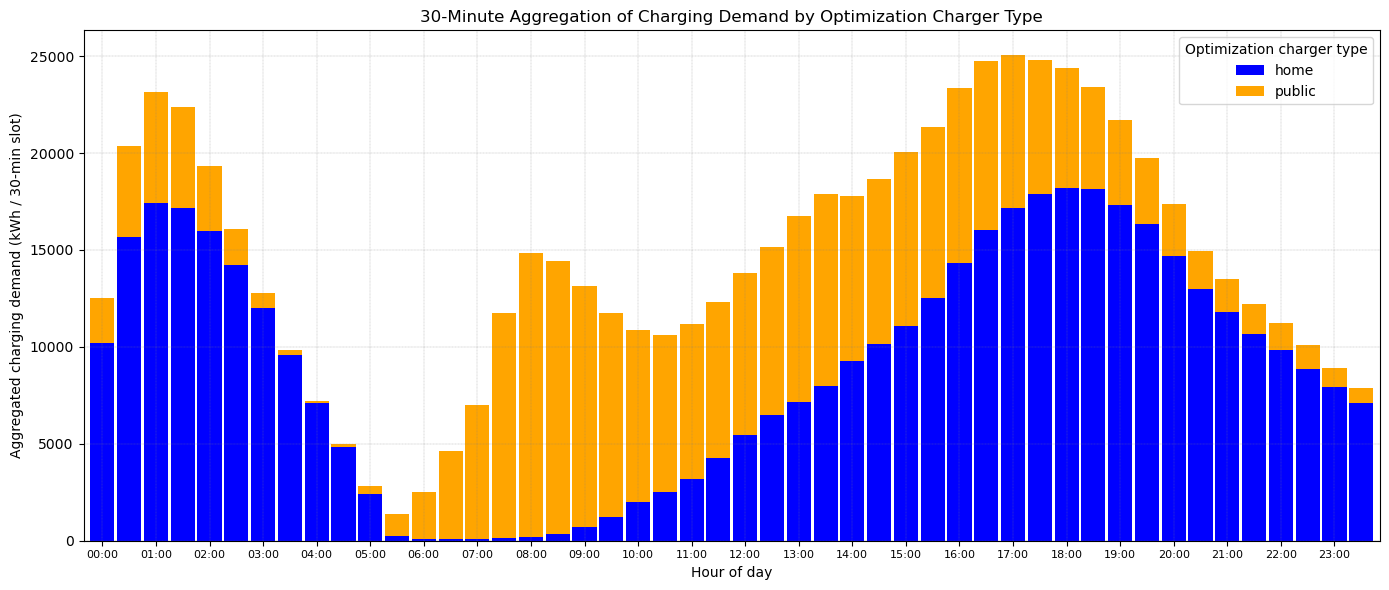

Temporal demand totals from plotted data:
chargerTypeOpt
home      431004.24
public    271542.45
dtype: float64


In [ ]:
# TEMPORAL PROFILE FROM SPATIAL GPKG
agg_df = (
    demand_gdf
    .groupby(["t", "chargerTypeOpt"], as_index=False)[DEMAND_COL]
    .sum()
)

pivot_df = (
    agg_df
    .pivot(index="t", columns="chargerTypeOpt", values=DEMAND_COL)
    .fillna(0.0)
    .sort_index()
)

for col in ["home", "public"]:
    if col not in pivot_df.columns:
        pivot_df[col] = 0.0

pivot_df = pivot_df[["home", "public"]]

pivot_df.index = (pivot_df.index - 1) / 2

ax = pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    width=0.9,
    color=["blue", "orange"]
)

ax.set_title("30-Minute Aggregation of Charging Demand by Optimization Charger Type")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Aggregated charging demand (kWh / 30-min slot)")

ax.set_xticks(range(0, len(pivot_df), 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=0, fontsize=8)

plt.legend(title="Optimization charger type")
plt.grid(True, color="grey", linewidth=0.2, linestyle="--")
plt.tight_layout()

if SAVE_FIGURES:
    temporal_fig_path = os.path.join(FIG_DIR, f"temporal_profile_{DEMAND_COL}.png")
    plt.savefig(temporal_fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved temporal profile figure: {temporal_fig_path}")

plt.show()

print("Temporal demand totals from plotted data:")
print(pivot_df.sum().round(2))

In [ ]:
# HEX LEVEL SPATIAL AGGREGATION

hex_geometry = (
    demand_gdf[["HexID", "geometry"]]
    .drop_duplicates(subset=["HexID"])
    .copy()
)

hex_by_type = (
    demand_gdf
    .groupby(["HexID", "chargerTypeOpt"], as_index=False)[DEMAND_COL]
    .sum()
)

hex_wide = (
    hex_by_type
    .pivot(index="HexID", columns="chargerTypeOpt", values=DEMAND_COL)
    .fillna(0.0)
    .reset_index()
)

for col in ["home", "public"]:
    if col not in hex_wide.columns:
        hex_wide[col] = 0.0

hex_wide["total_demand_kWh"] = hex_wide["home"] + hex_wide["public"]
hex_wide["public_share_percent"] = 100 * hex_wide["public"] / hex_wide["total_demand_kWh"].replace(0, pd.NA)
hex_wide["home_share_percent"] = 100 * hex_wide["home"] / hex_wide["total_demand_kWh"].replace(0, pd.NA)

hex_summary_gdf = hex_geometry.merge(hex_wide, on="HexID", how="left")
hex_summary_gdf = gpd.GeoDataFrame(hex_summary_gdf, geometry="geometry", crs=demand_gdf.crs)

# Fill possible empty cells
for col in ["home", "public", "total_demand_kWh", "public_share_percent", "home_share_percent"]:
    hex_summary_gdf[col] = hex_summary_gdf[col].fillna(0.0)

print("Hex-level spatial summary:")
print(f"- Active hex cells: {len(hex_summary_gdf):,}")
print(f"- Total demand from hex summary: {hex_summary_gdf['total_demand_kWh'].sum():,.2f} kWh/day")
print(f"- Max hex demand: {hex_summary_gdf['total_demand_kWh'].max():,.2f} kWh/day")

Hex-level spatial summary:
- Active hex cells: 638
- Total demand from hex summary: 702,546.69 kWh/day
- Max hex demand: 8,795.00 kWh/day


Saved figure: 30minData\full_full\figures\map_total_daily_demand_with_basemap_Demand_fullscale_kWh_full.png


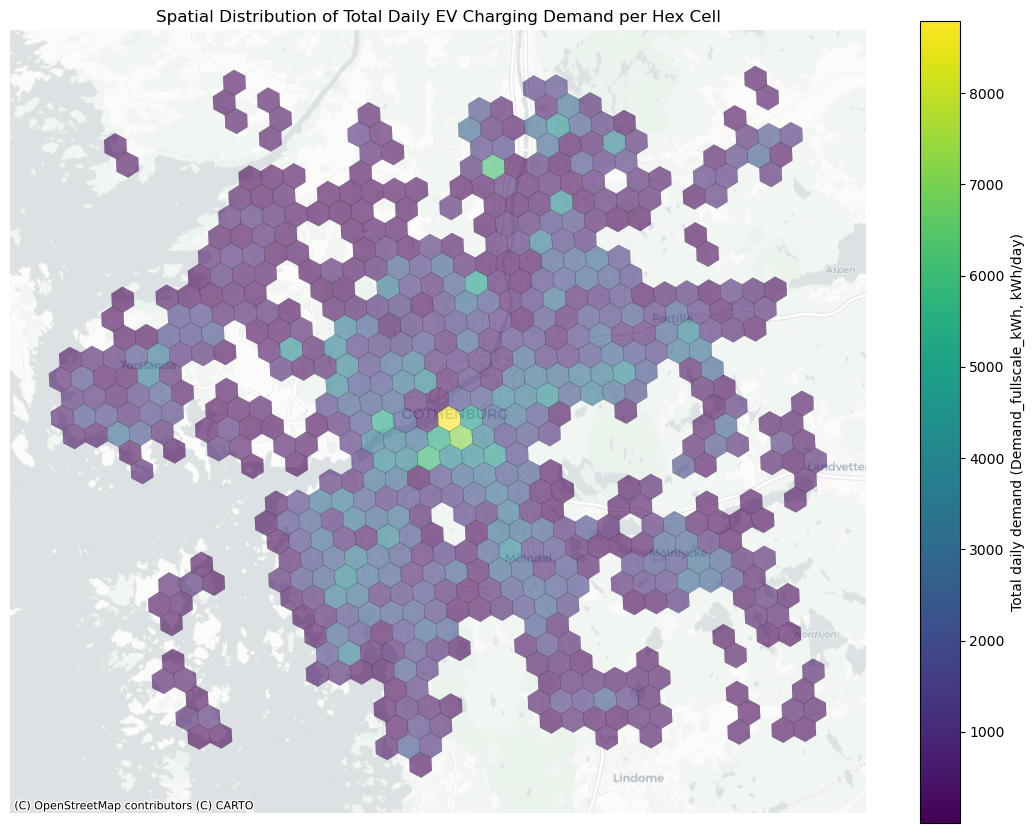

In [ ]:
# SPATIAL TOTAL DAILY DEMAND PER HEX WITH BASEMAP
def plot_hex_map_with_basemap(
    gdf,
    column,
    title,
    legend_label,
    output_filename,
    cmap="viridis",
    fill_alpha=0.60,
    edgecolor="black",
    linewidth=0.15,
):
    """Plot a hex choropleth with a web basemap at 80% alpha."""
    gdf_3857 = gdf.to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(11, 11))

    minx, miny, maxx, maxy = gdf_3857.total_bounds
    pad_x = (maxx - minx) * 0.05
    pad_y = (maxy - miny) * 0.05
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    try:
        ctx.add_basemap(
            ax,
            source=BASEMAP_SOURCE,
            crs=gdf_3857.crs,
            zoom="auto",
            alpha=BASEMAP_ALPHA,
        )
    except Exception as e:
        print("Error adding basemap:", e)

    gdf_3857.plot(
        column=column,
        ax=ax,
        legend=True,
        cmap=cmap,
        edgecolor=edgecolor,
        linewidth=linewidth,
        alpha=fill_alpha,
        zorder=2,
        legend_kwds={"label": legend_label, "shrink": 0.75},
    )

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()

    if SAVE_FIGURES:
        output_path = Path(FIG_DIR) / output_filename
        plt.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {output_path}")

    plt.show()


plot_hex_map_with_basemap(
    hex_summary_gdf,
    column="total_demand_kWh",
    title="Spatial Distribution of Total Daily EV Charging Demand per Hex Cell",
    legend_label=f"Total daily demand ({DEMAND_COL}, kWh/day)",
    output_filename=f"map_total_daily_demand_with_basemap_{DEMAND_COL}_{sample_tag}.png",
    cmap="viridis",
    fill_alpha=0.60,
)

Saved figure: 30minData\full_full\figures\map_home_daily_demand_with_basemap_Demand_fullscale_kWh_full.png


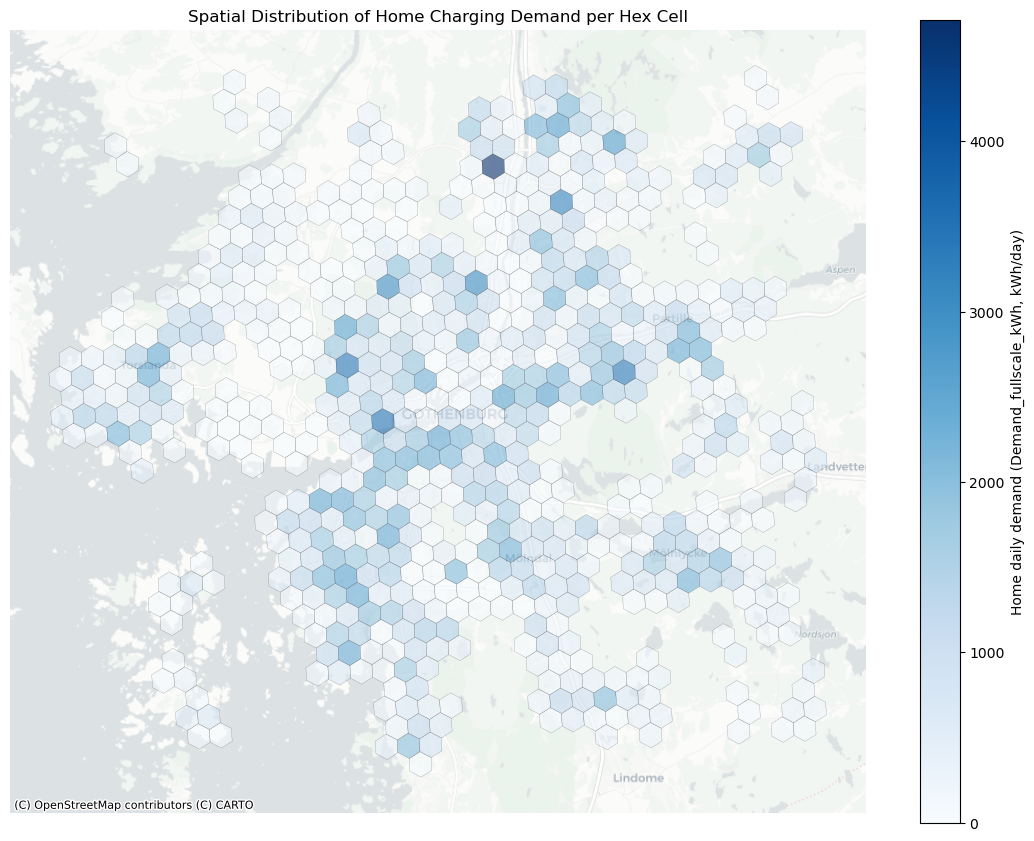

In [ ]:
# SPATIAL HOME DEMAND PER HEX WITH BASEMAP
plot_hex_map_with_basemap(
    hex_summary_gdf,
    column="home",
    title="Spatial Distribution of Home Charging Demand per Hex Cell",
    legend_label=f"Home daily demand ({DEMAND_COL}, kWh/day)",
    output_filename=f"map_home_daily_demand_with_basemap_{DEMAND_COL}_{sample_tag}.png",
    cmap="Blues",
    fill_alpha=0.60,
)

Saved figure: 30minData\full_full\figures\map_public_daily_demand_with_basemap_Demand_fullscale_kWh_full.png


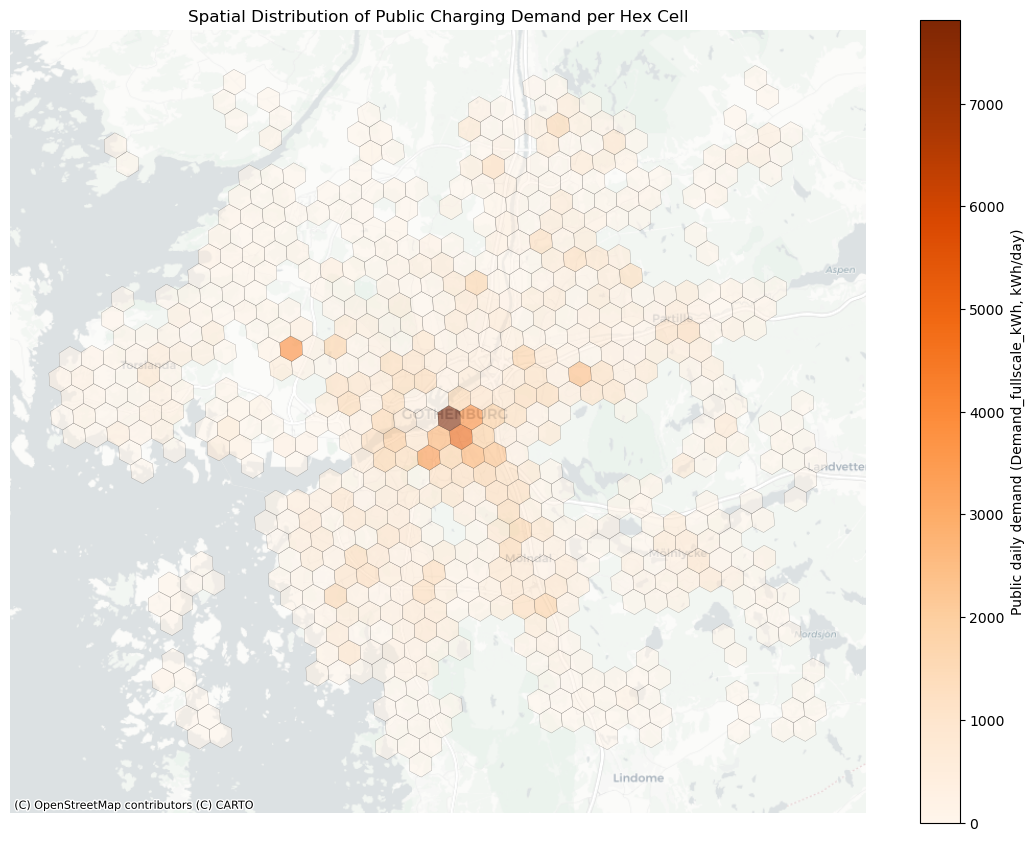

In [ ]:
#  SPATIAL PUBLIC DEMAND PER HEX
plot_hex_map_with_basemap(
    hex_summary_gdf,
    column="public",
    title="Spatial Distribution of Public Charging Demand per Hex Cell",
    legend_label=f"Public daily demand ({DEMAND_COL}, kWh/day)",
    output_filename=f"map_public_daily_demand_with_basemap_{DEMAND_COL}_{sample_tag}.png",
    cmap="Oranges",
    fill_alpha=0.60,
)

Saved figure: 30minData\full_full\figures\map_peak_30min_demand_with_basemap_Demand_fullscale_kWh_full.png


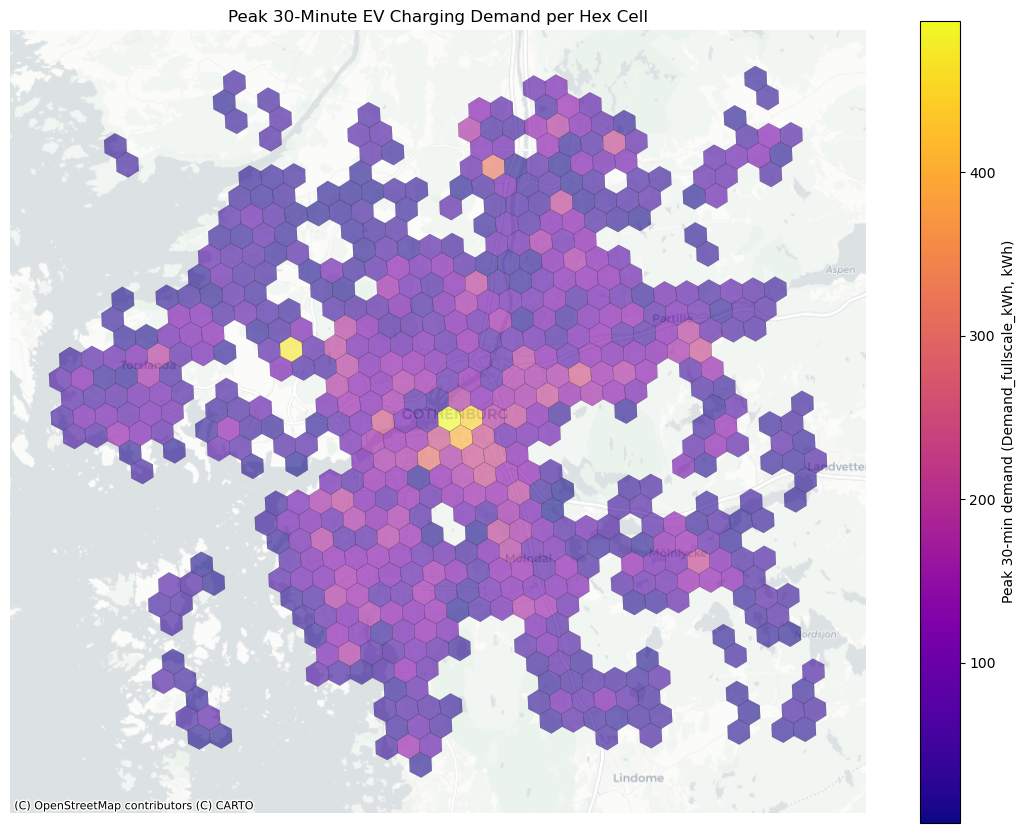

In [ ]:
# PEAK 30-MINUTE DEMAND PER HEX
hex_slot_total = (
    demand_gdf
    .groupby(["HexID", "t"], as_index=False)[DEMAND_COL]
    .sum()
)

idx_peak = hex_slot_total.groupby("HexID")[DEMAND_COL].idxmax()
hex_peak = hex_slot_total.loc[idx_peak].copy()

hex_peak = hex_peak.rename(columns={
    "t": "peak_t",
    DEMAND_COL: "peak_30min_demand_kWh"
})

hex_peak["peak_hour"] = (hex_peak["peak_t"] - 1) / 2
hex_peak["peak_hour_label"] = hex_peak["peak_hour"].apply(
    lambda x: f"{int(x):02d}:{int((x % 1) * 60):02d}"
)

hex_peak_gdf = hex_geometry.merge(hex_peak, on="HexID", how="left")
hex_peak_gdf = gpd.GeoDataFrame(hex_peak_gdf, geometry="geometry", crs=demand_gdf.crs)

plot_hex_map_with_basemap(
    hex_peak_gdf,
    column="peak_30min_demand_kWh",
    title="Peak 30-Minute EV Charging Demand per Hex Cell",
    legend_label=f"Peak 30-min demand ({DEMAND_COL}, kWh)",
    output_filename=f"map_peak_30min_demand_with_basemap_{DEMAND_COL}_{sample_tag}.png",
    cmap="plasma",
    fill_alpha=0.60,
)

In [27]:
top_hex = (
    hex_summary_gdf
    .drop(columns="geometry")
    .sort_values("total_demand_kWh", ascending=False)
    .head(10)
)

print("Top 10 hex cells by total representative daily demand:")
display(top_hex)

top_peak = (
    hex_peak_gdf
    .drop(columns="geometry")
    .sort_values("peak_30min_demand_kWh", ascending=False)
    .head(10)
)

print("Top 10 hex cells by peak 30-minute demand:")
display(top_peak)

Top 10 hex cells by total representative daily demand:


,HexID,home,public,total_demand_kWh,public_share_percent,home_share_percent
298,298,980.000000,7815.0,8795.000000,88.857305,11.142695
274,274,2120.969461,5080.0,7200.969461,70.546057,29.453943
586,586,4713.074845,1387.5,6100.574845,22.743758,77.256242
253,253,2274.806016,3652.5,5927.306016,61.621586,38.378414
273,273,2502.323891,2840.0,5342.323891,53.160386,46.839614
295,295,3563.497996,1692.5,5255.997996,32.201306,67.798694
483,483,3063.514905,1790.0,4853.514905,36.880488,63.119512
299,299,833.002194,4005.0,4838.002194,82.782104,17.217896
256,256,2182.087290,2467.5,4649.587290,53.069226,46.930774
618,618,2614.300424,1630.0,4244.300424,38.404444,61.595556


Top 10 hex cells by peak 30-minute demand:


,HexID,peak_t,peak_30min_demand_kWh,peak_hour,peak_hour_label
298,298,17,492.753092,8.0,08:00
393,393,17,467.025010,8.0,08:00
299,299,17,443.358198,8.0,08:00
274,274,28,400.276030,13.5,13:30
586,586,34,313.836143,16.5,16:30
253,253,18,299.745068,8.5,08:30
352,352,18,246.586135,8.5,08:30
295,295,31,243.120039,15.0,15:00
273,273,19,234.509367,9.0,09:00
275,275,18,231.960339,8.5,08:30


# Shortest Path

In [28]:
gdf = hex_summary_gdf
gdf = gdf.drop_duplicates(subset=["HexID"]).reset_index(drop=True)
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   HexID                 638 non-null    str     
 1   geometry              638 non-null    geometry
 2   home                  638 non-null    float64 
 3   public                638 non-null    float64 
 4   total_demand_kWh      638 non-null    float64 
 5   public_share_percent  638 non-null    float64 
 6   home_share_percent    638 non-null    float64 
dtypes: float64(5), geometry(1), str(1)
memory usage: 35.0 KB


In [29]:
shapefile_path = r"C:\Users\omkarp\Downloads\Opti2\OptiData\Shortest\GotRds.shp"
roads = gpd.read_file(shapefile_path)
if roads.crs.to_string() != "EPSG:3006":   roads = roads.to_crs(epsg=3006)
roads.head(2)

,name,name_en,highway,surface,smoothness,width,lanes,oneway,bridge,layer,source,name_sv,osm_id,osm_type,geometry
0,NaN,None,footway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,217420136,ways_line,"LINESTRING (318652.764 6398277.13, 318651.419 ..."
1,NaN,None,path,asphalt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1294969387,ways_line,"LINESTRING (318679.6 6398691.93, 318700.031 63..."


In [30]:
roads['highway'].unique()

<StringArray>
[       'footway',           'path',      'secondary',       'tertiary',
    'residential',   'unclassified',        'service', 'secondary_link',
       'platform',       'corridor',          'track',       'motorway',
          'steps',      'bridleway',  'living_street',     'pedestrian',
       'cycleway',        'primary',   'primary_link',     'trunk_link',
          'trunk',   'construction',  'motorway_link',  'tertiary_link',
        'raceway',       'proposed']
Length: 26, dtype: str

In [ ]:
from pathlib import Path
import time
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

from shapely.geometry import Point, LineString
from tqdm.notebook import tqdm

try:
    from scipy.spatial import cKDTree
except Exception:
    cKDTree = None
CRS_PROJECTED = "EPSG:3006"

OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SP_OUTPUT_CSV = Path(OUT_DISTANCE_CSV)
SP_OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
MAX_NETWORK_DISTANCE_M = 1500.0
WRITE_DIRECTED_ARCS = True
INCLUDE_SELF_ARCS = False
KEEP_LARGEST_ROAD_COMPONENT = True
SNAP_MAX_DISTANCE_M = None
SAVE_PATH_GEOMETRIES = False

def load_final_hexes_for_shortest_paths():
    """
    Loads the final optimization hex set with continuous HexID numbering.
    This guarantees that shortestpath.csv uses the same HexID numbering
    as the demand input used by the optimization model.
    """

    if "demand_opt_legacy" in globals():
        hexes = (
            demand_opt_legacy[["HexID", "geometry"]]
            .drop_duplicates(subset="HexID")
            .copy()
        )
        source = "in-memory demand_opt_legacy"

    elif "hex_grid_active" in globals():
        hexes = hex_grid_active[["HexID", "geometry"]].copy()
        source = "in-memory hex_grid_active"

    else:
        candidate_paths = [
            Path(OUT_DEMAND_GPKG),
            Path(OUTPUT_DIR) / f"demandHexGrid_optimization_{sample_tag}.gpkg",
            Path(OUTPUT_DIR) / f"demand_30min_hex_home_public_{sample_tag}.gpkg",
            Path(OUTPUT_DIR) / f"hex_grid_active_{sample_tag}.gpkg",
        ]

        found = None
        for p in candidate_paths:
            if p.exists():
                found = p
                break

        if found is None:
            raise FileNotFoundError(
                "Could not find final hex source. "
                "Run the demand/hex generation cell first, or set a path manually."
            )

        if "demandHexGrid" in found.name:
            hexes = (
                gpd.read_file(found, layer="demandHexGrid")[["HexID", "geometry"]]
                .drop_duplicates(subset="HexID")
                .copy()
            )
        else:
            hexes = gpd.read_file(found)[["HexID", "geometry"]].copy()

        source = str(found)

    if hexes.crs is None:
        hexes = hexes.set_crs(CRS_PROJECTED)
    elif str(hexes.crs) != CRS_PROJECTED:
        hexes = hexes.to_crs(CRS_PROJECTED)

    hexes = hexes[hexes.geometry.notna() & ~hexes.geometry.is_empty].copy()

    hexes["HexID"] = pd.to_numeric(hexes["HexID"], errors="raise").astype(np.int32)
    hexes = (
        hexes
        .drop_duplicates(subset="HexID")
        .sort_values("HexID")
        .reset_index(drop=True)
    )

    # Confirm continuous numbering
    hex_ids = hexes["HexID"].astype(int).tolist()
    expected = list(range(len(hex_ids)))
    if hex_ids != expected:
        raise ValueError(
            "HexID values are not continuous. "
            "Regenerate/reassign HexID before computing shortest paths."
        )

    hexes["centroid"] = hexes.geometry.centroid

    print("Loaded final hex set for shortest paths.")
    print(f"- Source: {source}")
    print(f"- Hex cells: {len(hexes):,}")
    print(f"- HexID range: {hexes['HexID'].min()} to {hexes['HexID'].max()}")
    print(f"- CRS: {hexes.crs}")
    print()

    return hexes


def load_roads_for_graph(roads_path):
    roads = gpd.read_file(roads_path)

    if roads.crs is None:
        raise ValueError("Road network has no CRS. Set it before running shortest paths.")

    if str(roads.crs) != CRS_PROJECTED:
        roads = roads.to_crs(CRS_PROJECTED)

    roads = roads[roads.geometry.notna() & ~roads.geometry.is_empty].copy()

    if "highway" in roads.columns:
        roads = roads[roads["highway"].notna()].copy()

    print("Loaded road network.")
    print(f"- Path: {roads_path}")
    print(f"- Road features: {len(roads):,}")
    print(f"- CRS: {roads.crs}")
    print()

    return roads

def iter_lines(geom):
    """
    Yields LineString geometries from LineString or MultiLineString.
    """
    if geom is None or geom.is_empty:
        return

    if geom.geom_type == "LineString":
        yield geom

    elif geom.geom_type == "MultiLineString":
        for line in geom.geoms:
            if line is not None and not line.is_empty:
                yield line


def build_road_graph_fast(roads):
    """
    Build an undirected weighted graph from road geometries.
    Faster than using Point(a).distance(Point(b)) repeatedly:
    weights are computed with numpy hypot.
    """

    G = nx.Graph()

    for geom in tqdm(roads.geometry, total=len(roads), desc="Building road graph"):
        for line in iter_lines(geom):
            coords = np.asarray(line.coords, dtype=float)

            if len(coords) < 2:
                continue

            # Use only x,y in case geometries have z values
            xy = coords[:, :2]

            for k in range(len(xy) - 1):
                a = (float(xy[k, 0]), float(xy[k, 1]))
                b = (float(xy[k + 1, 0]), float(xy[k + 1, 1]))

                dx = b[0] - a[0]
                dy = b[1] - a[1]
                dist = float(np.hypot(dx, dy))

                if dist <= 0:
                    continue

                # If duplicate edge exists, keep the shorter weight
                if G.has_edge(a, b):
                    if dist < G[a][b].get("weight", np.inf):
                        G[a][b]["weight"] = dist
                else:
                    G.add_edge(a, b, weight=dist)

    print("Road graph built.")
    print(f"- Nodes: {G.number_of_nodes():,}")
    print(f"- Edges: {G.number_of_edges():,}")

    if G.number_of_nodes() == 0 or G.number_of_edges() == 0:
        raise ValueError("Road graph is empty. Check road shapefile and CRS.")

    return G


def keep_largest_component(G):
    """
    Keeps only the largest connected component of an undirected road graph.
    """

    components = list(nx.connected_components(G))

    if len(components) <= 1:
        print("- Road graph has one connected component.")
        return G

    largest_nodes = max(components, key=len)
    G_largest = G.subgraph(largest_nodes).copy()

    print("Road graph component filtering:")
    print(f"- Connected components before filtering: {len(components):,}")
    print(f"- Nodes before: {G.number_of_nodes():,}")
    print(f"- Nodes after largest component: {G_largest.number_of_nodes():,}")
    print(f"- Edges after largest component: {G_largest.number_of_edges():,}")
    print()

    return G_largest


def match_hexes_to_nearest_graph_nodes(hexes, G, snap_max_distance_m=None):
    """
    Vectorized centroid-to-nearest-road-node matching using cKDTree.
    """

    if cKDTree is None:
        raise ImportError(
            "scipy.spatial.cKDTree is required for this fast nearest-node matching."
        )

    nodes = list(G.nodes)
    node_arr = np.asarray(nodes, dtype=float)

    tree = cKDTree(node_arr)

    centroid_arr = np.column_stack([
        hexes["centroid"].x.to_numpy(dtype=float),
        hexes["centroid"].y.to_numpy(dtype=float)
    ])

    dist, idx = tree.query(centroid_arr, k=1)

    matched = hexes.copy()
    matched["nearest_node"] = [nodes[int(i)] for i in idx]
    matched["snap_dist_m"] = dist.astype(float)

    if snap_max_distance_m is not None:
        before = len(matched)
        matched = matched[matched["snap_dist_m"] <= snap_max_distance_m].copy()
        after = len(matched)

        print("Snap-distance filtering:")
        print(f"- Before: {before:,}")
        print(f"- After:  {after:,}")
        print(f"- Removed: {before - after:,}")
        print()

        if matched.empty:
            raise ValueError(
                "No hexes remained after snap-distance filtering. "
                "Increase SNAP_MAX_DISTANCE_M or set it to None."
            )

    print("Matched hex centroids to graph nodes.")
    print(f"- Hexes matched: {len(matched):,}")
    print(f"- Unique nearest graph nodes: {matched['nearest_node'].nunique():,}")
    print(f"- Max snap distance: {matched['snap_dist_m'].max():,.2f} m")
    print(f"- Mean snap distance: {matched['snap_dist_m'].mean():,.2f} m")
    print()

    return matched

def compute_shortestpath_csv_fast(
    hexes,
    roads_path,
    output_csv,
    max_network_distance_m=1500.0,
    write_directed_arcs=True,
    include_self_arcs=False,
    keep_largest_road_component=True,
    snap_max_distance_m=None,
    save_path_geometries=False
):
    """
    Computes shortest-path distances between final optimization hex cells.

    Output CSV is compatible with:
        get_distance_dict(csv_path)

    Required output columns:
        from_HexID, to_HexID, distance
    """

    t0 = time.time()

    roads = load_roads_for_graph(roads_path)
    G = build_road_graph_fast(roads)

    if keep_largest_road_component:
        G = keep_largest_component(G)

    hexes_matched = match_hexes_to_nearest_graph_nodes(
        hexes,
        G,
        snap_max_distance_m=snap_max_distance_m
    )

    hex_ids = hexes_matched["HexID"].astype(int).to_numpy()
    nearest_nodes = hexes_matched["nearest_node"].to_numpy()

    hex_to_node = dict(zip(hex_ids, nearest_nodes))
    hex_to_centroid = dict(zip(hex_ids, hexes_matched["centroid"]))

    unique_source_nodes = list(dict.fromkeys(nearest_nodes.tolist()))

    print("Shortest-path run setup:")
    print(f"- Hex cells used: {len(hex_ids):,}")
    print(f"- Unique source graph nodes: {len(unique_source_nodes):,}")
    print(f"- Directed arcs: {write_directed_arcs}")
    print(f"- Include self arcs: {include_self_arcs}")
    print(f"- Dijkstra cutoff: {max_network_distance_m}")
    print()

    all_lengths = {}

    for source_node in tqdm(unique_source_nodes, desc="Single-source Dijkstra"):
        all_lengths[source_node] = nx.single_source_dijkstra_path_length(
            G,
            source_node,
            cutoff=max_network_distance_m,
            weight="weight"
        )

    rows = []

    target_hex_ids = hex_ids.tolist()

    for from_hex in tqdm(hex_ids.tolist(), desc="Assembling shortestpath.csv"):
        src_node = hex_to_node[from_hex]
        src_lengths = all_lengths[src_node]
        src_centroid = hex_to_centroid[from_hex]

        for to_hex in target_hex_ids:
            if from_hex == to_hex and not include_self_arcs:
                continue

            if (not write_directed_arcs) and (to_hex <= from_hex):
                continue

            dst_node = hex_to_node[to_hex]

            network_m = src_lengths.get(dst_node, np.nan)

            if pd.isna(network_m):
                continue

            if max_network_distance_m is not None and network_m > max_network_distance_m:
                continue

            dst_centroid = hex_to_centroid[to_hex]
            euclidean_m = float(src_centroid.distance(dst_centroid))

            rows.append({
                "from_HexID": int(from_hex),
                "to_HexID": int(to_hex),
                "distance": float(network_m),
                "euclidean_m": euclidean_m,
                "from_node_x": float(src_node[0]),
                "from_node_y": float(src_node[1]),
                "to_node_x": float(dst_node[0]),
                "to_node_y": float(dst_node[1]),
            })

    dist_df = pd.DataFrame(rows)

    if dist_df.empty:
        raise ValueError(
            "No shortest-path rows were generated. "
            "Check MAX_NETWORK_DISTANCE_M, road graph connectivity, and hex-road snapping."
        )

    # Enforce expected dtypes
    dist_df["from_HexID"] = dist_df["from_HexID"].astype(int)
    dist_df["to_HexID"] = dist_df["to_HexID"].astype(int)
    dist_df["distance"] = dist_df["distance"].astype(float)

    dist_df = (
        dist_df
        .sort_values(["from_HexID", "to_HexID"])
        .reset_index(drop=True)
    )

    output_csv = Path(output_csv)
    output_csv.parent.mkdir(parents=True, exist_ok=True)
    dist_df.to_csv(output_csv, index=False)

    print("Shortest-path CSV written.")
    print(f"- File: {output_csv}")
    print(f"- Rows: {len(dist_df):,}")
    print(f"- Unique from_HexID: {dist_df['from_HexID'].nunique():,}")
    print(f"- Unique to_HexID: {dist_df['to_HexID'].nunique():,}")
    print(f"- Min distance: {dist_df['distance'].min():,.2f} m")
    print(f"- Max distance: {dist_df['distance'].max():,.2f} m")
    print(f"- Mean distance: {dist_df['distance'].mean():,.2f} m")
    print()

    if write_directed_arcs:
        pair_count = len(dist_df)
        reverse_check = dist_df.merge(
            dist_df[["from_HexID", "to_HexID", "distance"]],
            left_on=["from_HexID", "to_HexID"],
            right_on=["to_HexID", "from_HexID"],
            suffixes=("", "_reverse")
        )

        print("Directed-pair check:")
        print(f"- Rows with reverse counterpart: {len(reverse_check):,} / {pair_count:,}")
        print()

    if save_path_geometries:
        line_rows = []

        for r in tqdm(dist_df.itertuples(index=False), total=len(dist_df), desc="Creating centroid lines"):
            c1 = hex_to_centroid[int(r.from_HexID)]
            c2 = hex_to_centroid[int(r.to_HexID)]

            line_rows.append({
                "from_HexID": int(r.from_HexID),
                "to_HexID": int(r.to_HexID),
                "distance": float(r.distance),
                "euclidean_m": float(r.euclidean_m),
                "geometry": LineString([c1, c2])
            })

        lines_gdf = gpd.GeoDataFrame(line_rows, geometry="geometry", crs=CRS_PROJECTED)
        lines_path = output_csv.with_suffix(".gpkg")
        lines_gdf.to_file(lines_path, layer="shortest_paths_centroid_lines", driver="GPKG")
        print(f"Diagnostic centroid-line GPKG written: {lines_path}")

    hexes_save = hexes_matched.drop(columns=["centroid"]).copy()
    hexes_save = gpd.GeoDataFrame(hexes_save, geometry="geometry", crs=CRS_PROJECTED)

    matched_hex_path = output_csv.parent / "hexes_used_for_shortestpath.gpkg"
    hexes_save.to_file(matched_hex_path, layer="hexes_used_for_shortestpath", driver="GPKG")

    print(f"Matched hexes saved: {matched_hex_path}")
    print(f"Runtime: {(time.time() - t0) / 60:.2f} minutes")

    return dist_df, hexes_matched, G


hexes_for_sp = load_final_hexes_for_shortest_paths()

dist_df, hexes_for_sp, road_graph = compute_shortestpath_csv_fast(
    hexes=hexes_for_sp,
    roads_path=ROADS_PATH,
    output_csv=SP_OUTPUT_CSV,
    max_network_distance_m=MAX_NETWORK_DISTANCE_M,
    write_directed_arcs=WRITE_DIRECTED_ARCS,
    include_self_arcs=INCLUDE_SELF_ARCS,
    keep_largest_road_component=KEEP_LARGEST_ROAD_COMPONENT,
    snap_max_distance_m=SNAP_MAX_DISTANCE_M,
    save_path_geometries=SAVE_PATH_GEOMETRIES
)

display(dist_df.head())

Loaded final hex set for shortest paths.
- Source: in-memory demand_opt_legacy
- Hex cells: 638
- HexID range: 0 to 637
- CRS: EPSG:3006

Loaded road network.
- Path: C:\Users\omkarp\Downloads\Opti2\OptiData\Shortest\GotRds.shp
- Road features: 117,343
- CRS: EPSG:3006



Building road graph:   0%|          | 0/117343 [00:00<?, ?it/s]

Road graph built.
- Nodes: 722,994
- Edges: 752,189
Road graph component filtering:
- Connected components before filtering: 7,282
- Nodes before: 722,994
- Nodes after largest component: 620,322
- Edges after largest component: 654,850

Matched hex centroids to graph nodes.
- Hexes matched: 638
- Unique nearest graph nodes: 631
- Max snap distance: 5,766.47 m
- Mean snap distance: 187.68 m

Shortest-path run setup:
- Hex cells used: 638
- Unique source graph nodes: 631
- Directed arcs: True
- Include self arcs: False
- Dijkstra cutoff: 1500.0



Single-source Dijkstra:   0%|          | 0/631 [00:00<?, ?it/s]

Assembling shortestpath.csv:   0%|          | 0/638 [00:00<?, ?it/s]

Shortest-path CSV written.
- File: C:\Users\omkarp\Downloads\Opti\data\raw\full\shortestpath.csv
- Rows: 1,598
- Unique from_HexID: 559
- Unique to_HexID: 559
- Min distance: 0.00 m
- Max distance: 1,499.58 m
- Mean distance: 1,158.14 m

Directed-pair check:
- Rows with reverse counterpart: 1,598 / 1,598

Matched hexes saved: C:\Users\omkarp\Downloads\Opti\data\raw\full\hexes_used_for_shortestpath.gpkg
Runtime: 0.54 minutes


,from_HexID,to_HexID,distance,euclidean_m,from_node_x,from_node_y,to_node_x,to_node_y
0,0,3,1203.760547,866.025404,317343.608325,6.386415e+06,317759.581490,6.387262e+06
1,1,2,1323.336750,866.025404,316080.034202,6.387263e+06,316875.123267,6.387245e+06
2,2,1,1323.336750,866.025404,316875.123267,6.387245e+06,316080.034202,6.387263e+06
3,2,3,1412.959689,866.025404,316875.123267,6.387245e+06,317759.581490,6.387262e+06
4,2,12,1041.828633,866.025404,316875.123267,6.387245e+06,317295.599082,6.387954e+06


In [32]:
dist_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1598 entries, 0 to 1597
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   from_HexID   1598 non-null   int64  
 1   to_HexID     1598 non-null   int64  
 2   distance     1598 non-null   float64
 3   euclidean_m  1598 non-null   float64
 4   from_node_x  1598 non-null   float64
 5   from_node_y  1598 non-null   float64
 6   to_node_x    1598 non-null   float64
 7   to_node_y    1598 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 100.0 KB


In [33]:
dist_df[dist_df['distance']<1200].nunique()

from_HexID     430
to_HexID       430
distance       615
euclidean_m     63
from_node_x    423
from_node_y    423
to_node_x      423
to_node_y      423
dtype: int64

Loaded hexes for shortest-path visualization:
- Source: in-memory hexes_for_sp
- Hex cells: 638
- CRS: EPSG:3006

Shortest-path distance table for plotting:
- Rows after distance filter: 1,598
- Max plotted network distance: 1,499.58 m

OD diagnostic lines:
- Lines plotted: 1,598

Saved figure: 30minData\full_full\figures\shortest_paths_od_links_with_basemap.png


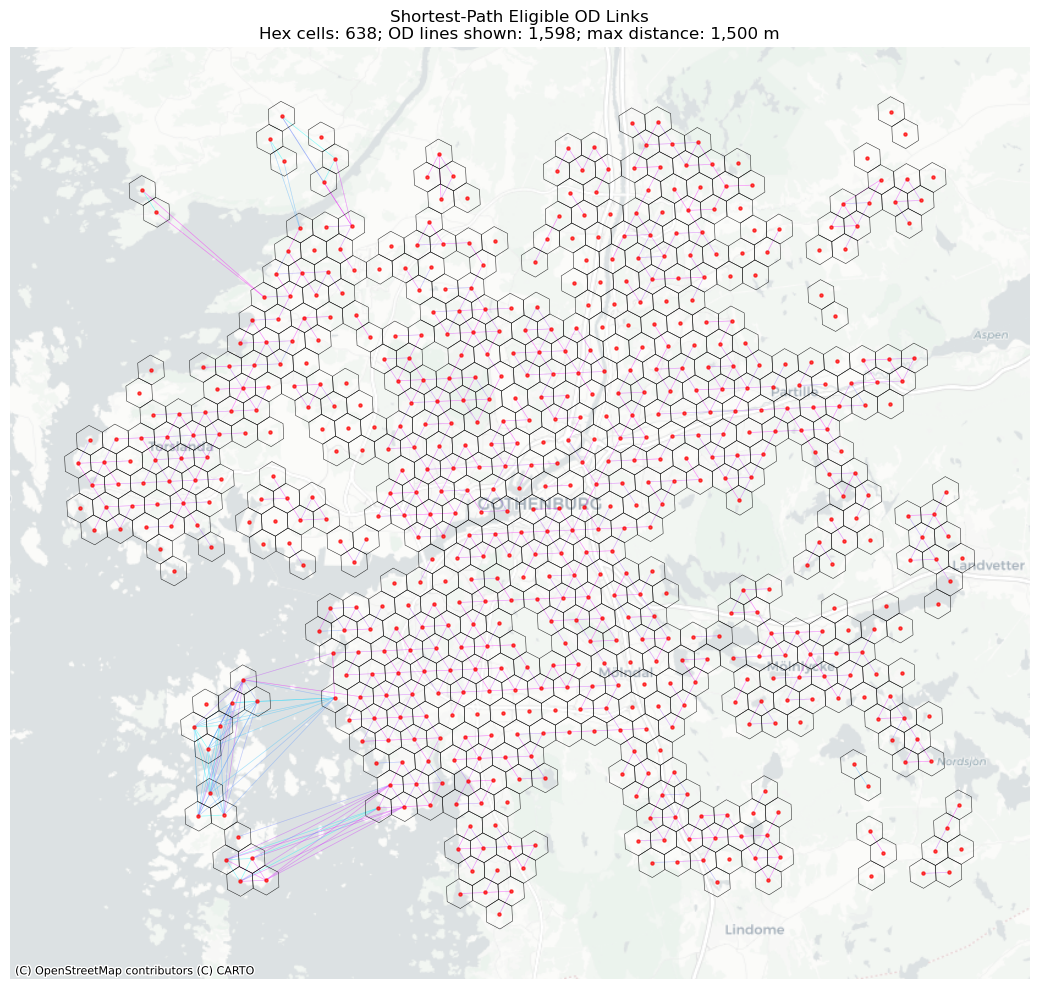

In [ ]:
CRS_PROJECTED = "EPSG:3006"

try:
    SP_OUTPUT_CSV
except NameError:
    SP_OUTPUT_CSV = Path(OUT_DISTANCE_CSV)

try:
    FIG_DIR
except NameError:
    FIG_DIR = Path(FIG_DIR)

os.makedirs(FIG_DIR, exist_ok=True)

SAVE_FIGURES = True
MAX_OD_LINES_TO_PLOT = 2500
MAX_DISTANCE_TO_PLOT_M = 1500.0
PLOT_TRUE_NETWORK_PATH_SAMPLE = True
N_TRUE_PATHS_TO_PLOT = 50
BASEMAP_SOURCE = BASEMAP_SOURCE if "BASEMAP_SOURCE" in globals() else ctx.providers.CartoDB.Positron

def get_hexes_used_for_shortestpath():
    """
    Returns the final hex GeoDataFrame used in shortest-path generation.
    """

    if "hexes_for_sp" in globals():
        h = hexes_for_sp.copy()
        source = "in-memory hexes_for_sp"

    elif "hexes_used_for_shortestpath" in globals():
        h = hexes_used_for_shortestpath.copy()
        source = "in-memory hexes_used_for_shortestpath"

    else:
        candidate_path = Path(OUT_DISTANCE_CSV).parent / "hexes_used_for_shortestpath.gpkg"

        if candidate_path.exists():
            h = gpd.read_file(candidate_path, layer="hexes_used_for_shortestpath")
            source = str(candidate_path)

        elif "hex_grid_active" in globals():
            h = hex_grid_active.copy()
            source = "in-memory hex_grid_active"

        else:
            raise FileNotFoundError(
                "Could not find hexes used for shortest paths. "
                "Run shortest-path generation first."
            )

    if h.crs is None:
        h = h.set_crs(CRS_PROJECTED)
    elif str(h.crs) != CRS_PROJECTED:
        h = h.to_crs(CRS_PROJECTED)

    h["HexID"] = pd.to_numeric(h["HexID"], errors="raise").astype(int)
    h = h.drop_duplicates(subset="HexID").sort_values("HexID").reset_index(drop=True)
    h["HexID"] = h["HexID"].astype(str)

    if "centroid" not in h.columns:
        h["centroid"] = h.geometry.centroid

    print("Loaded hexes for shortest-path visualization:")
    print(f"- Source: {source}")
    print(f"- Hex cells: {len(h):,}")
    print(f"- CRS: {h.crs}")
    print()

    return h


hexes_used_for_shortestpath = get_hexes_used_for_shortestpath()

if "dist_df" not in globals():
    dist_df = pd.read_csv(SP_OUTPUT_CSV)

required_dist_cols = ["from_HexID", "to_HexID", "distance"]
missing = [c for c in required_dist_cols if c not in dist_df.columns]
if missing:
    raise ValueError(f"dist_df is missing required columns: {missing}")

dist_plot = dist_df.copy()
dist_plot["from_HexID"] = dist_plot["from_HexID"].astype(int)
dist_plot["to_HexID"] = dist_plot["to_HexID"].astype(int)
dist_plot["distance"] = pd.to_numeric(dist_plot["distance"], errors="coerce")

dist_plot = dist_plot.dropna(subset=["distance"]).copy()

if MAX_DISTANCE_TO_PLOT_M is not None:
    dist_plot = dist_plot[dist_plot["distance"] <= MAX_DISTANCE_TO_PLOT_M].copy()

print("Shortest-path distance table for plotting:")
print(f"- Rows after distance filter: {len(dist_plot):,}")
print(f"- Max plotted network distance: {dist_plot['distance'].max():,.2f} m")
print()

centroid_dict = {
    int(row.HexID): row.centroid
    for row in hexes_used_for_shortestpath.itertuples()
}

line_rows = []

if MAX_OD_LINES_TO_PLOT is not None and len(dist_plot) > MAX_OD_LINES_TO_PLOT:
    dist_plot_lines = (
        dist_plot
        .sample(n=MAX_OD_LINES_TO_PLOT, random_state=42)
        .sort_values(["from_HexID", "to_HexID"])
        .copy()
    )
else:
    dist_plot_lines = dist_plot.copy()

for r in dist_plot_lines.itertuples(index=False):
    from_id = int(r.from_HexID)
    to_id = int(r.to_HexID)

    if from_id not in centroid_dict or to_id not in centroid_dict:
        continue

    line_rows.append({
        "from_HexID": from_id,
        "to_HexID": to_id,
        "distance": float(r.distance),
        "geometry": LineString([centroid_dict[from_id], centroid_dict[to_id]])
    })

od_lines_gdf = gpd.GeoDataFrame(
    line_rows,
    geometry="geometry",
    crs=CRS_PROJECTED
)

print("OD diagnostic lines:")
print(f"- Lines plotted: {len(od_lines_gdf):,}")
print()

hexes_3857 = hexes_used_for_shortestpath.to_crs(epsg=3857)
od_lines_3857 = od_lines_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

minx, miny, maxx, maxy = hexes_3857.total_bounds
pad_x = (maxx - minx) * 0.06
pad_y = (maxy - miny) * 0.06

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

# Basemap
try:
    ctx.add_basemap(
        ax,
        source=BASEMAP_SOURCE,
        crs=hexes_3857.crs,
        zoom="auto",
        alpha=BASEMAP_ALPHA
    )
except Exception as e:
    print("Error adding basemap:", e)

if not od_lines_3857.empty:
    od_lines_3857.plot(
        ax=ax,
        column="distance",
        cmap="cool",
        linewidth=0.45,
        alpha=0.25,
        legend=False,
        zorder=2
    )

hexes_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.35,
    alpha=0.9,
    zorder=3
)

centroid_points = gpd.GeoDataFrame(
    hexes_used_for_shortestpath[["HexID"]].copy(),
    geometry=hexes_used_for_shortestpath.geometry.centroid,
    crs=CRS_PROJECTED
).to_crs(epsg=3857)

centroid_points.plot(
    ax=ax,
    color="red",
    markersize=5,
    alpha=0.7,
    zorder=4
)

ax.set_title(
    f"Shortest-Path Eligible OD Links\n"
    f"Hex cells: {len(hexes_used_for_shortestpath):,}; "
    f"OD lines shown: {len(od_lines_gdf):,}; "
    f"max distance: {MAX_DISTANCE_TO_PLOT_M:,.0f} m"
)

ax.set_axis_off()
plt.tight_layout()

if SAVE_FIGURES:
    out_path = os.path.join(FIG_DIR, "shortest_paths_od_links_with_basemap.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {out_path}")

plt.show()

True network path sample:
- Requested path pairs: 50
- True paths created: 50

Saved figure: 30minData\full_full\figures\shortest_paths_true_network_sample_with_basemap.png


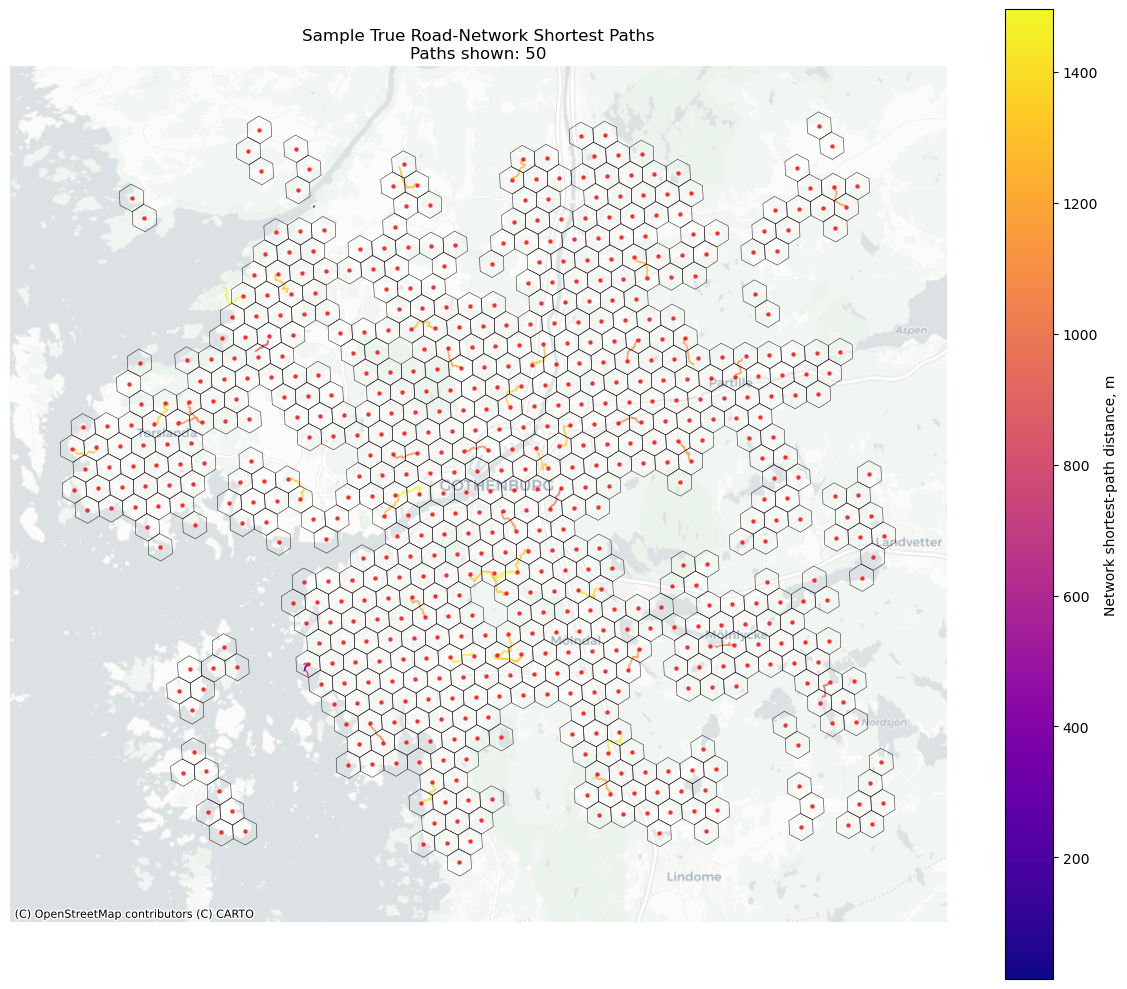

In [ ]:
import networkx as nx

if PLOT_TRUE_NETWORK_PATH_SAMPLE:
    if "road_graph" not in globals():
        print("road_graph not found. Run shortest-path generation first to plot true network paths.")

    elif "nearest_node" not in hexes_used_for_shortestpath.columns:
        print(
            "nearest_node column not found in hexes_used_for_shortpath. "
            "Use hexes_for_sp returned from shortest-path generation, or reload hexes_used_for_shortpath.gpkg."
        )

    else:
        # Sample shortest-path pairs
        if len(dist_plot) > N_TRUE_PATHS_TO_PLOT:
            path_pairs = dist_plot.sample(n=N_TRUE_PATHS_TO_PLOT, random_state=7).copy()
        else:
            path_pairs = dist_plot.copy()

        node_dict = {
            int(row.HexID): row.nearest_node
            for row in hexes_used_for_shortestpath.itertuples()
        }

        true_path_rows = []

        for r in path_pairs.itertuples(index=False):
            from_id = int(r.from_HexID)
            to_id = int(r.to_HexID)

            if from_id not in node_dict or to_id not in node_dict:
                continue

            src_node = node_dict[from_id]
            dst_node = node_dict[to_id]

            try:
                node_path = nx.shortest_path(
                    road_graph,
                    source=src_node,
                    target=dst_node,
                    weight="weight"
                )

                if len(node_path) >= 2:
                    true_path_rows.append({
                        "from_HexID": from_id,
                        "to_HexID": to_id,
                        "distance": float(r.distance),
                        "geometry": LineString(node_path)
                    })

            except Exception:
                continue

        true_paths_gdf = gpd.GeoDataFrame(
            true_path_rows,
            geometry="geometry",
            crs=CRS_PROJECTED
        )

        print("True network path sample:")
        print(f"- Requested path pairs: {len(path_pairs):,}")
        print(f"- True paths created: {len(true_paths_gdf):,}")
        print()

        if not true_paths_gdf.empty:
            true_paths_3857 = true_paths_gdf.to_crs(epsg=3857)

            fig, ax = plt.subplots(figsize=(12, 10))

            minx, miny, maxx, maxy = hexes_3857.total_bounds
            pad_x = (maxx - minx) * 0.06
            pad_y = (maxy - miny) * 0.06

            ax.set_xlim(minx - pad_x, maxx + pad_x)
            ax.set_ylim(miny - pad_y, maxy + pad_y)

            try:
                ctx.add_basemap(
                    ax,
                    source=BASEMAP_SOURCE,
                    crs=hexes_3857.crs,
                    zoom="auto",
                    alpha=BASEMAP_ALPHA
                )
            except Exception as e:
                print("Error adding basemap:", e)

            true_paths_3857.plot(
                ax=ax,
                column="distance",
                cmap="plasma",
                linewidth=1.2,
                alpha=BASEMAP_ALPHA,
                legend=True,
                zorder=3,
                legend_kwds={"label": "Network shortest-path distance, m"}
            )

            hexes_3857.plot(
                ax=ax,
                facecolor="none",
                edgecolor="black",
                linewidth=0.35,
                alpha=0.9,
                zorder=4
            )

            centroid_points.plot(
                ax=ax,
                color="red",
                markersize=5,
                alpha=0.7,
                zorder=5
            )

            ax.set_title(
                f"Sample True Road-Network Shortest Paths\n"
                f"Paths shown: {len(true_paths_gdf):,}"
            )

            ax.set_axis_off()
            plt.tight_layout()

            if SAVE_FIGURES:
                out_path = Path(FIG_DIR) / "shortest_paths_true_network_sample_with_basemap.png"
                plt.savefig(out_path, dpi=300, bbox_inches="tight")
                print(f"Saved figure: {out_path}")

            plt.show()

# Charger parking data

In [ ]:
OUTPUT_CHARPARK_SHP = Path(OUT_CHARPARK_SHP)
OUTPUT_CHARPARK_GPKG = Path(OUT_CHARPARK_GPKG)
OUTPUT_CHARPARK_SHP.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_CHARPARK_GPKG.parent.mkdir(parents=True, exist_ok=True)
PARKING_EFF = 0.5
PARKING_SPOT_M2 = 15.0
SOLAR_EFFECTIVE_AREA_PER_PANEL = 300.0

ADD_MIN_PARKING_CAP = 15
ADD_MIN_HOMECHAR = 5

VILLA_TAGS = [
    "house", "detached", "bungalow", "semidetached_house",
    "garage", "garages", "cabin", "allotment_house"
]

DEFAULT_SPOTS_BY_TAG = {
    "house": 2,
    "detached": 2,
    "bungalow": 1,
    "semidetached_house": 1,
    "garage": 1,
    "garages": 1,
    "cabin": 1,
    "allotment_house": 1,
}


def remove_shapefile_sidecars(shp_path):
    shp_path = Path(shp_path)
    for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg", ".qix", ".fix"]:
        p = shp_path.with_suffix(ext)
        if p.exists():
            p.unlink()


def read_vector_layer(path, target_crs=CRS_PROJECTED):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Input file not found: {path}")

    gdf = gpd.read_file(path)
    if gdf.crs is None:
        raise ValueError(f"Layer has no CRS: {path}")
    if str(gdf.crs) != target_crs:
        gdf = gdf.to_crs(target_crs)
    return gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()


def load_final_hexes_for_charpark():
    """Load final optimization hexes with continuous HexID values."""
    if "hex_grid_active" in globals():
        hexes = hex_grid_active[["HexID", "geometry"]].copy()
        source = "in-memory hex_grid_active"
    elif "demand_opt_legacy" in globals():
        hexes = demand_opt_legacy[["HexID", "geometry"]].drop_duplicates(subset="HexID").copy()
        source = "in-memory demand_opt_legacy"
    else:
        found = Path(OUT_DEMAND_GPKG)
        if not found.exists():
            raise FileNotFoundError("Could not find final demand file. Run demand generation first.")
        hexes = (
            gpd.read_file(found, layer="demandHexGrid")[["HexID", "geometry"]]
            .drop_duplicates(subset="HexID")
            .copy()
        )
        source = str(found)

    if hexes.crs is None:
        hexes = hexes.set_crs(CRS_PROJECTED)
    elif str(hexes.crs) != CRS_PROJECTED:
        hexes = hexes.to_crs(CRS_PROJECTED)

    hexes = hexes[hexes.geometry.notna() & ~hexes.geometry.is_empty].copy()
    hexes["HexID"] = pd.to_numeric(hexes["HexID"], errors="raise").astype(int)
    hexes = hexes.drop_duplicates(subset="HexID").sort_values("HexID").reset_index(drop=True)

    actual_hexids = hexes["HexID"].tolist()
    expected_hexids = list(range(len(hexes)))
    if actual_hexids != expected_hexids:
        raise ValueError("Final hexes do not have continuous HexID numbering.")

    hexes["HexID"] = hexes["HexID"].astype(str)
    print("Loaded final hexes for CharPark:")
    print(f"- Source: {source}")
    print(f"- Hex cells: {len(hexes):,}")
    print(f"- HexID range: 0 to {len(hexes) - 1}")
    print(f"- CRS: {hexes.crs}")
    print()
    return hexes


final_hexes = load_final_hexes_for_charpark()
hexg = final_hexes[["HexID", "geometry"]].copy()

parking_src = read_vector_layer(PARKING_PATH)
solar_src = read_vector_layer(SOLAR_PATH)
home_src = read_vector_layer(HOMECHARGING_PATH)

print("Loaded source layers:")
print(f"- Parking features: {len(parking_src):,}")
print(f"- Solar features:   {len(solar_src):,}")
print(f"- Home features:    {len(home_src):,}")
print()

parking_inter = gpd.overlay(
    hexg[["HexID", "geometry"]],
    parking_src[["geometry"]],
    how="intersection"
)

if parking_inter.empty:
    parking_agg = pd.DataFrame({"HexID": final_hexes["HexID"], "ParkingCap": 0})
else:
    parking_inter["Park_area"] = parking_inter.geometry.area
    parking_inter["Effective_area"] = parking_inter["Park_area"] * PARKING_EFF
    parking_inter["Raw_spots"] = parking_inter["Effective_area"] / PARKING_SPOT_M2
    parking_inter["ParkingCapacity"] = np.floor(parking_inter["Raw_spots"]).clip(lower=0).astype(int)

    parking_agg = (
        parking_inter
        .groupby("HexID", as_index=False)
        .agg(Park_area=("Park_area", "sum"), ParkingCapacity=("ParkingCapacity", "sum"))
    )

    Q1 = parking_agg["ParkingCapacity"].quantile(0.25)
    Q3 = parking_agg["ParkingCapacity"].quantile(0.75)
    IQR = Q3 - Q1
    upper_fence = Q3 + 1.5 * IQR

    parking_agg["ParkingCap_capped"] = np.where(
        parking_agg["ParkingCapacity"] > upper_fence,
        upper_fence,
        parking_agg["ParkingCapacity"]
    )

    S = parking_agg["ParkingCapacity"].sum()
    min_c = parking_agg["ParkingCapacity"].min()
    max_c = parking_agg["ParkingCapacity"].max()
    target = 0.7 * S

    denom = np.sum(parking_agg["ParkingCapacity"] * (parking_agg["ParkingCapacity"] - min_c))
    reduction_max = ((S - target) * (max_c - min_c) / denom) if denom != 0 else 0

    def adjusted_cap(cap):
        if max_c <= min_c:
            return int(cap)
        r = reduction_max * (cap - min_c) / (max_c - min_c)
        r = np.clip(r, 0, 1)
        return int(np.ceil(cap * (1 - r)))

    parking_agg["ParkingCap"] = parking_agg["ParkingCapacity"].apply(adjusted_cap).astype(int)
    parking_agg = parking_agg[["HexID", "ParkingCap"]]

solar_inter = gpd.overlay(
    hexg[["HexID", "geometry"]],
    solar_src[["geometry"]],
    how="intersection"
)

if solar_inter.empty:
    panel_agg = pd.DataFrame({"HexID": final_hexes["HexID"], "Panels": 0})
else:
    solar_inter["intersect_area_m2"] = solar_inter.geometry.area
    solar_inter["Panels"] = np.floor(
        solar_inter["intersect_area_m2"] / SOLAR_EFFECTIVE_AREA_PER_PANEL
    ).clip(lower=0).astype(int)

    panel_agg = (
        solar_inter
        .groupby("HexID", as_index=False)
        .agg(solar_area_m2=("intersect_area_m2", "sum"), Panels=("Panels", "sum"))
    )[["HexID", "Panels"]]


if "type" not in home_src.columns:
    raise ValueError("HOMECHARGING_PATH layer lacks a 'type' column, but homeChar logic requires it.")

bldgs = home_src.copy()
bldgs["type_clean"] = bldgs["type"].astype(str).str.lower().str.strip()
villas = bldgs[bldgs["type_clean"].isin(VILLA_TAGS)].copy()

if villas.empty:
    home_agg = pd.DataFrame({"HexID": final_hexes["HexID"], "homeChar": 0})
else:
    villas["area_m2"] = villas.geometry.area
    villas["geometry"] = villas.geometry.representative_point()

    villas["parkSpots_area"] = np.ceil(villas["area_m2"] / 90.0).clip(lower=0).astype(int)
    villas["parkSpots_tag"] = villas["type_clean"].map(DEFAULT_SPOTS_BY_TAG).fillna(villas["parkSpots_area"]).astype(int)
    villas["parkSpots_avg"] = np.ceil((villas["parkSpots_tag"] + villas["parkSpots_area"]) / 2.0).clip(lower=0).astype(int)

    villas_pts = villas[["parkSpots_avg", "geometry"]].set_geometry("geometry")
    joined_home = gpd.sjoin(
        villas_pts,
        hexg[["HexID", "geometry"]],
        how="inner",
        predicate="within"
    )

    if joined_home.empty:
        home_agg = pd.DataFrame({"HexID": final_hexes["HexID"], "homeChar": 0})
    else:
        home_agg = (
            joined_home
            .groupby("HexID", as_index=False)["parkSpots_avg"]
            .sum()
            .rename(columns={"parkSpots_avg": "sum_spots"})
        )
        home_agg["homeChar"] = np.ceil(home_agg["sum_spots"] / 2.0).clip(lower=0).astype(int)
        home_agg = home_agg[["HexID", "homeChar"]]

charpark = final_hexes[["HexID", "geometry"]].copy()
charpark = charpark.merge(parking_agg, on="HexID", how="left")
charpark = charpark.merge(panel_agg, on="HexID", how="left")
charpark = charpark.merge(home_agg, on="HexID", how="left")

charpark["ParkingCap"] = charpark["ParkingCap"].fillna(0).astype(float)
charpark["Panels"] = charpark["Panels"].fillna(0).astype(float)
charpark["homeChar"] = charpark["homeChar"].fillna(0).astype(float)

charpark["ParkingCap"] = charpark["ParkingCap"] + ADD_MIN_PARKING_CAP
charpark["homeChar"] = charpark["homeChar"] + ADD_MIN_HOMECHAR

charpark["HexID"] = charpark["HexID"].astype(str)
charpark["ParkingCap"] = np.ceil(charpark["ParkingCap"]).clip(lower=0).astype("int64")
charpark["Panels"] = np.floor(charpark["Panels"]).clip(lower=0).astype(float)
charpark["homeChar"] = np.ceil(charpark["homeChar"]).clip(lower=0).astype("int32")

charpark = charpark[["HexID", "ParkingCap", "Panels", "homeChar", "geometry"]].copy()
charpark = gpd.GeoDataFrame(charpark, geometry="geometry", crs=CRS_PROJECTED)

hexid_ints = sorted(charpark["HexID"].astype(int).tolist())
expected_hexids = list(range(len(charpark)))
if hexid_ints != expected_hexids:
    raise ValueError("CharPark HexID numbering is not continuous.")

print("CharPark summary:")
print(f"- Output variant: {DATA_VARIANT}")
print(f"- Rows / hex cells: {len(charpark):,}")
print(f"- ParkingCap total: {charpark['ParkingCap'].sum():,}")
print(f"- Panels total:     {charpark['Panels'].sum():,.0f}")
print(f"- homeChar total:   {charpark['homeChar'].sum():,}")
print(f"- SOLAR_EFFECTIVE_AREA_PER_PANEL: {SOLAR_EFFECTIVE_AREA_PER_PANEL:,.1f} m²/panel-count unit")
print()

charpark.info()
print()
display(charpark.head())

remove_shapefile_sidecars(OUTPUT_CHARPARK_SHP)
if OUTPUT_CHARPARK_GPKG.exists():
    OUTPUT_CHARPARK_GPKG.unlink()

charpark.to_file(OUTPUT_CHARPARK_GPKG, layer=CHARPARK_FILE_STEM, driver="GPKG")
charpark.to_file(OUTPUT_CHARPARK_SHP, driver="ESRI Shapefile")

print("CharPark outputs saved:")
print(f"- GeoPackage: {OUTPUT_CHARPARK_GPKG}")
print(f"- Shapefile:  {OUTPUT_CHARPARK_SHP}")

Loaded final hexes for CharPark:
- Source: in-memory hex_grid_active
- Hex cells: 638
- HexID range: 0 to 637
- CRS: EPSG:3006

Loaded source layers:
- Parking features: 10,263
- Solar features:   1
- Home features:    98,440

CharPark summary:
- Output variant: full
- Rows / hex cells: 638
- ParkingCap total: 126,866
- Panels total:     248,575
- homeChar total:   22,744
- SOLAR_EFFECTIVE_AREA_PER_PANEL: 300.0 m²/panel-count unit

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   HexID       638 non-null    str     
 1   ParkingCap  638 non-null    int64   
 2   Panels      638 non-null    float64 
 3   homeChar    638 non-null    int32   
 4   geometry    638 non-null    geometry
dtypes: float64(1), geometry(1), int32(1), int64(1), str(1)
memory usage: 22.6 KB



,HexID,ParkingCap,Panels,homeChar,geometry
0,0,102,31.0,5,"POLYGON ((317308.54 6386994.173, 317741.553 63..."
1,1,21,190.0,5,"POLYGON ((316009.502 6387744.173, 316442.514 6..."
2,2,519,453.0,5,"POLYGON ((316875.527 6387744.173, 317308.54 63..."
3,3,322,574.0,5,"POLYGON ((317741.553 6387744.173, 318174.565 6..."
4,4,15,315.0,5,"POLYGON ((324669.756 6387744.173, 325102.768 6..."


CharPark outputs saved:
- GeoPackage: C:\Users\omkarp\Downloads\Opti\data\raw\full\CharParkfull.gpkg
- Shapefile:  C:\Users\omkarp\Downloads\Opti\data\raw\full\CharParkfull.shp


In [ ]:
print(f'shapefileDemands = r"{OUT_DEMAND_GPKG}"')
print(f'csv_distance_path = r"{OUT_DISTANCE_CSV}"')
print(f'parking   = r"{OUT_CHARPARK_SHP}"')

Done. Copy-paste these paths into the optimization notebook:

shapefileDemands = r"C:\Users\omkarp\Downloads\Opti\data\raw\full\demandHexGrid_optimization_full.gpkg"
csv_distance_path = r"C:\Users\omkarp\Downloads\Opti\data\raw\full\shortestpath.csv"
parking   = r"C:\Users\omkarp\Downloads\Opti\data\raw\full\CharParkfull.shp"
